# Assignment Two — 2025

## Data Preprocessing
- Simple statistical evaluation of the data set;
- Identify the target variable(s);
- Identify if this is a regression or a classification task;
- Are there any missing data? What can you do about them?
- Which variables are relevant or irrelevant to the task?
- What type of validation/cross-validation procedure will you use? 
- Data visualisation.

In [1259]:
# Install Package 
import numpy as np, seaborn as sns, matplotlib.pyplot as plt

import numpy as np
from numpy.random import normal

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns
import math

# Data splitting and model evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import  StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [1260]:
# Loading the data
data = pd.read_csv("Euro_6_latest.csv", 
                   encoding= 'latin1') # encoding = 'latin1' is required because in the dataset, 
                                       # there are special characters. Latin1 is an encoding for Western Europe. 
data.head()
# From the data.head() code, we see that there are 45 columns. However, in this dataset, the last column is 'unnamed:44' and there is no values in this column. 
# This is because the last column in the original dataset is 'Date of change' with a comma, thus, the pandas see it as a column and include it. Thus, this last column should be slided out.
# After the initial understanding of the meaning of each column in this dataset, the first three columns 'Manufacturere', 'Model', and 'Description', 'Noise Level dB (A)'


# Moreover, from the initial assessment, as the topic focuses on the car and emission, 'Noise Level dB (A)' is not relevant and it should be also dropped. 
# Similarly, 'Date of Change' column appears simply as an updated date of each row. Hence, it is dropped.

#

,Manufacturer,Model,Description,Transmission,Manual or Automatic,Engine Capacity,Fuel Type,Powertrain,Engine Power (PS),Engine Power (Kw),...,Electric Range City Km,Emissions CO [mg/km],THC Emissions [mg/km],Emissions NOx [mg/km],THC + NOx Emissions [mg/km],Particulates [No.] [mg/km],RDE NOx Urban,RDE NOx Combined,Noise Level dB(A),Date of change
0,ABARTH,500e MY23/24,114kW Electric (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
1,ABARTH,500e MY23/24,114kW Electric (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
2,ABARTH,500e MY23/24,114kW Electric Convertible (VL),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,359.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
3,ABARTH,500e MY23/24,114kW Electric Convertible (VH),A1,Electric - Not Applicable,0.0,Electricity,Battery Electric Vehicle (BEV) / Pure Electric...,155.0,114.0,...,330.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,68.0,17-Oct-24
4,ABARTH,595 MY23,Turismo 1.4 Tjet 165 hp Manual (VL),M5,Manual,1368.0,Petrol,Internal Combustion Engine (ICE),165.0,121.0,...,NaN,688.0,66.0,28.0,NaN,NaN,60.0,60.0,69.0,17-Oct-24


In [1261]:
print(f"Original data shape: {data.shape}")
print(f"Data rows: {data.shape[0]}, Data columns: {data.shape[1]}")

Original data shape: (3702, 44)
Data rows: 3702, Data columns: 44


In [1262]:
data.dtypes
# only data type for column 'Date of change' is not at the right match while the rest is correct. 

Manufacturer                              object
Model                                     object
Description                               object
Transmission                              object
Manual or Automatic                       object
Engine Capacity                          float64
Fuel Type                                 object
Powertrain                                object
Engine Power (PS)                        float64
Engine Power (Kw)                        float64
Electric energy consumption Miles/kWh    float64
wh/km                                    float64
Maximum range (Km)                       float64
Maximum range (Miles)                    float64
Euro Standard                             object
Diesel VED Supplement                       bool
Testing Scheme                            object
WLTP Imperial Low                        float64
WLTP Imperial Medium                     float64
WLTP Imperial High                       float64
WLTP Imperial Extra 

Unique fuel types: ['Electricity' 'Petrol' 'Diesel' 'Electricity / Petrol' 'Petrol Electric'
 'Petrol / LPG' 'Diesel Electric' 'Electricity / Diesel']
Number of categories: 8


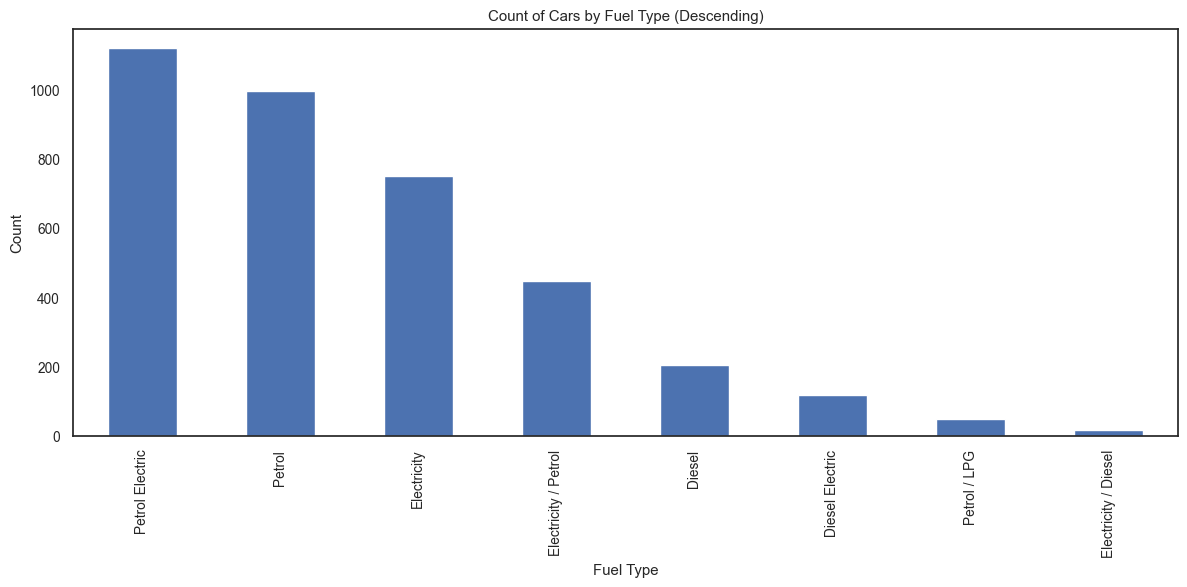

In [1263]:
# Examine categorical data from Fuel Type column
fuel_type_categories = data["Fuel Type"].unique()
print(f"Unique fuel types: {fuel_type_categories}")
print(f"Number of categories: {len(fuel_type_categories)}")

fuel_type_counts = data["Fuel Type"].value_counts().reindex(fuel_type_categories, fill_value=0)
sorted_counts = fuel_type_counts.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_counts.plot(kind="bar")
plt.title("Count of Cars by Fuel Type (Descending)")
plt.ylabel("Count")
plt.xlabel("Fuel Type")
plt.tight_layout()
plt.show()

/var/folders/jy/6jqk_b8s32361qm39cwcxqy40000gn/T/ipykernel_18857/2977562601.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/damian/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


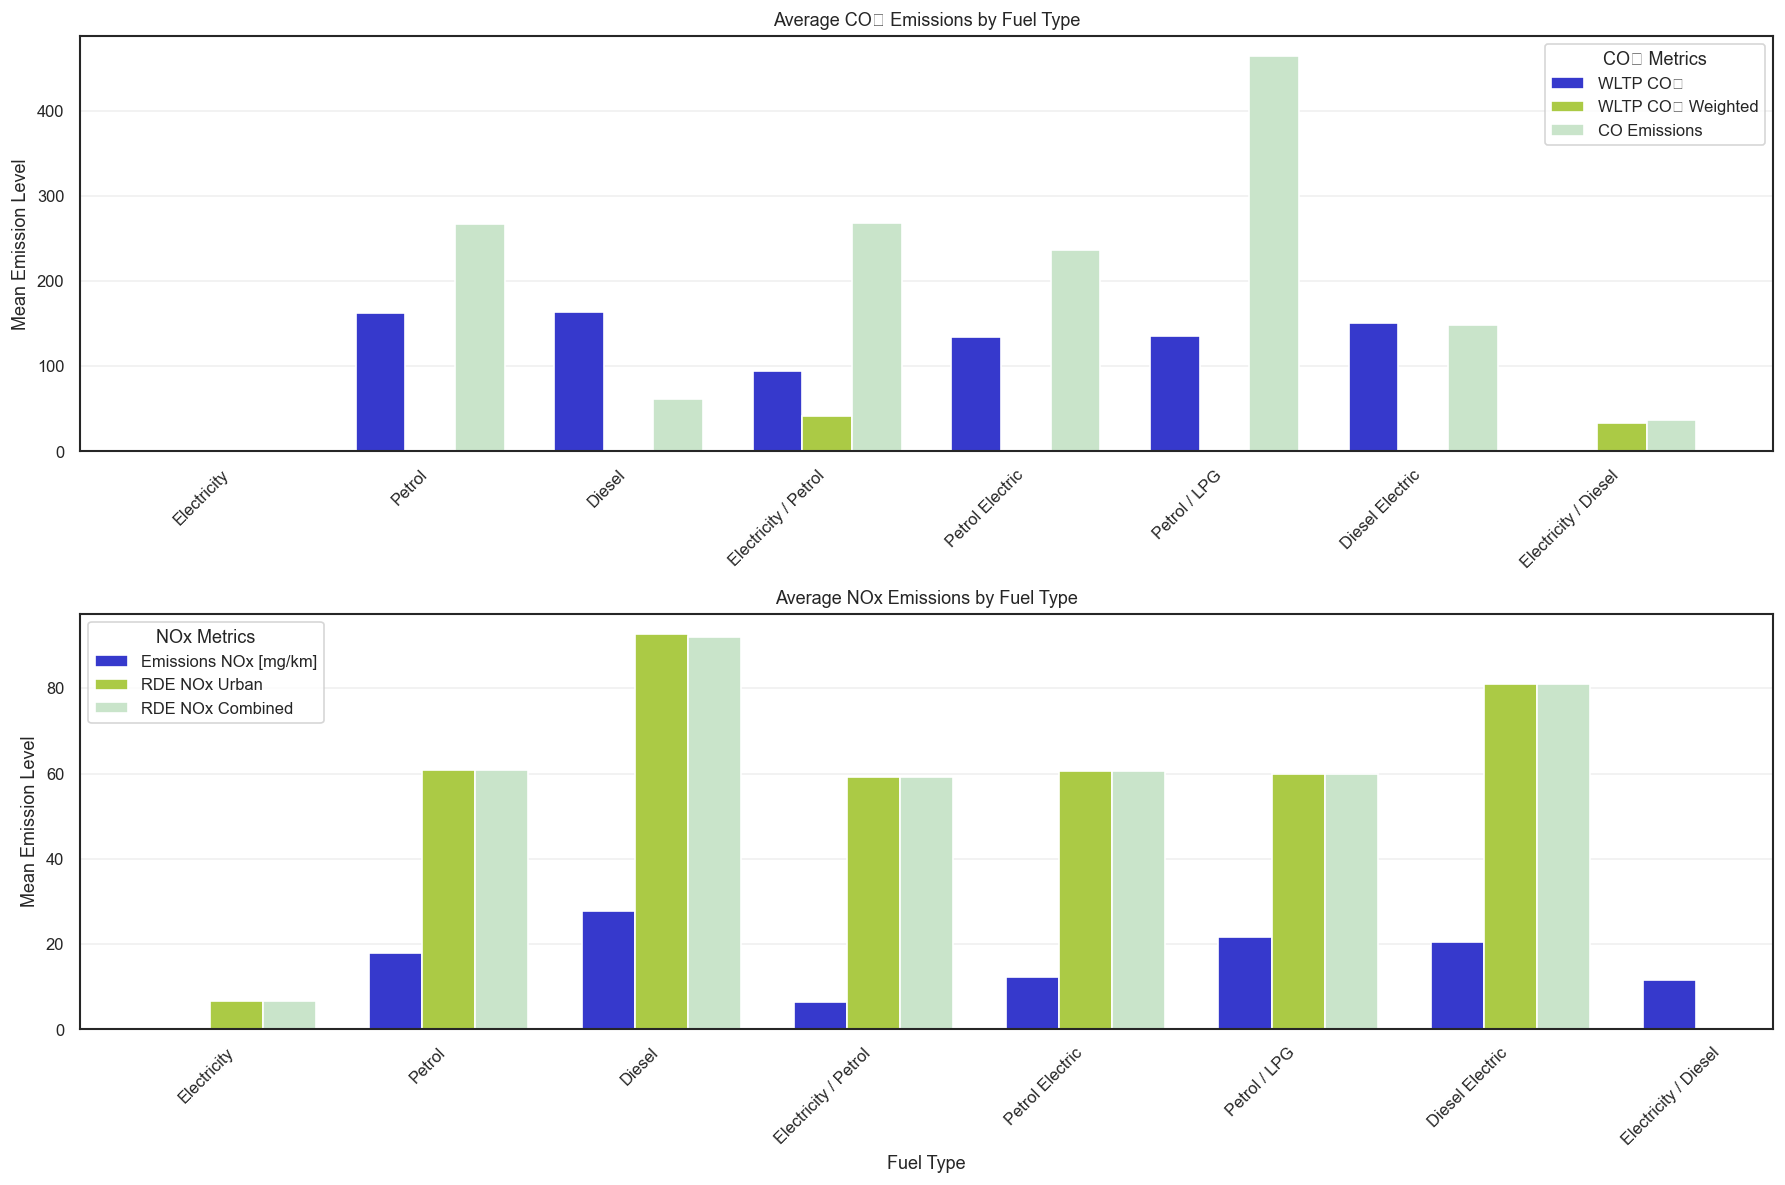

In [1264]:
# Set up for CO2 Average Emission from each metric
metrics_CO2 = ["WLTP CO2", "WLTP CO2 Weighted", "Emissions CO [mg/km]"]
CO2_emission_means = data.groupby("Fuel Type")[metrics_CO2].mean().reindex(fuel_type_categories)

# Set up for NOx Average Emission from each metric
metrics_NOx = ["Emissions NOx [mg/km]", "RDE NOx Urban", "RDE NOx Combined"]
NOx_emission_means = data.groupby("Fuel Type")[metrics_NOx].mean().reindex(fuel_type_categories)

# set up for visualisation 
x = np.arange(len(CO2_emission_means.index))  # positions for each fuel type
width = 0.25  # width of each bar
fig, axs = plt.subplots(2,1, figsize=(15,10), dpi=120)

# Visualise CO2 Emisison on the top
axs[0].bar(x - width, CO2_emission_means["WLTP CO2"], width, label="WLTP CO₂", color="#3639CC")
axs[0].bar(x, CO2_emission_means["WLTP CO2 Weighted"], width, label="WLTP CO₂ Weighted", color="#ABCA45")
axs[0].bar(x + width, CO2_emission_means["Emissions CO [mg/km]"], width, label="CO Emissions", color="#C9E4CA")

axs[0].set_title("Average CO₂ Emissions by Fuel Type")
axs[0].set_xlabel("")  # top plot usually omits x-label
axs[0].set_ylabel("Mean Emission Level")
axs[0].set_xticks(x)
axs[0].set_xticklabels(CO2_emission_means.index, rotation=45, ha="right")
axs[0].legend(title="CO₂ Metrics")
axs[0].grid(axis="y", alpha=0.3)

# Visualise NOx Emisison in the bottom
axs[1].bar(x - width, NOx_emission_means["Emissions NOx [mg/km]"], width, label="Emissions NOx [mg/km]", color="#3639CC")
axs[1].bar(x, NOx_emission_means["RDE NOx Urban"], width, label="RDE NOx Urban", color="#ABCA45")
axs[1].bar(x + width, NOx_emission_means["RDE NOx Combined"], width, label="RDE NOx Combined", color="#C9E4CA")

axs[1].set_title("Average NOx Emissions by Fuel Type")
axs[1].set_xlabel("Fuel Type")
axs[1].set_ylabel("Mean Emission Level")
axs[1].set_xticks(x)
axs[1].set_xticklabels(NOx_emission_means.index, rotation=45, ha="right")
axs[1].legend(title="NOx Metrics")
axs[1].grid(axis="y", alpha=0.3)

# show
fig.tight_layout()
plt.show()

**Conclusion**
* have enough data accross different fuel types. (Despite CO emissions have more, but not common as CO2)
* WLTP CO2 (wegihts) is excluded because it lacked data distrbution accorss fuel types.
* CO2 is more common to people understanding about gas emissions.

Pick Emissions NOx [mg/km] because:
* has difference mean across fuel type -> easier for comparison and prediction afterward.
* RDE NOx Urban and RDE NOx combined are nearly equal across different fuel types. Their mean values are not much different across fuel types.

Based on the two graphs, eletric cars have no CO2 emissions, and low NOx emissions as well (given the source state that NOx emissions from eletric car are from their battery). Therefore, all of the eletric cars will be excluded from the datasets. Given the distribution, two datasets will be created based on their fuel types - fuel cars only (data_fuel), and hybrid cars only (data_hybrid). Furthermore, since the target variables (WLTP CO2 and NO emissions) are not highly included in Eletricity /Diesel Fuel type, they will be removed from the data_hybrid

Based on the visualisation, following variables should be moved since they are not relevant


In [1265]:
removed_variables = [
    "Manufacturer", "Model", "Description",
    "Transmission", "Engine Power (Kw)", "Electric energy consumption Miles/kWh",
    "wh/km", "Maximum range (Km)", "Maximum range (Miles)",
    "Euro Standard", "Diesel VED Supplement", "Testing Scheme", 
    "WLTP CO2 Weighted", "Equivalent All Electric Range Miles", "Equivalent All Electric Range KM",
    "Electric Range City Miles", "Electric Range City Km", "Emissions CO [mg/km]",
    "THC Emissions [mg/km]", "THC + NOx Emissions [mg/km]", "Particulates [No.] [mg/km]",
    "RDE NOx Urban", "RDE NOx Combined", "Noise Level dB(A)", 
    "Date of change",
]

data = data.drop(columns=removed_variables)
print(f"Data shape after removing columns: {data.shape}")

Data shape after removing columns: (3702, 19)


In [1266]:
# Define fuel type categories for each group
# electric_types = ["Electricity"]

hybrid_types = [
    "Electricity / Petrol", "Petrol Electric",
    "Diesel Electric"]

fuel_types = [
    "Petrol", "Diesel", "Petrol / LPG"
]

# Split the dataset
# data_electric = data[data["Fuel Type"].isin(electric_types)] #Can remove since not relevant to the target variable
data_hybrid = data[data["Fuel Type"].isin(hybrid_types)]
data_fuel = data[data["Fuel Type"].isin(fuel_types)]

# print(f"Electric cars: {data_electric.shape[0]} rows")
print(f"Hybrid cars: {data_hybrid.shape[0]} rows")
print(f"Fuel cars: {data_fuel.shape[0]} rows")
# print(f"Original data: {data.shape[0]} rows ") #To check whether the split is correct

Hybrid cars: 1686 rows
Fuel cars: 1250 rows


Dataset shape before removing NA values: (1250, 19)


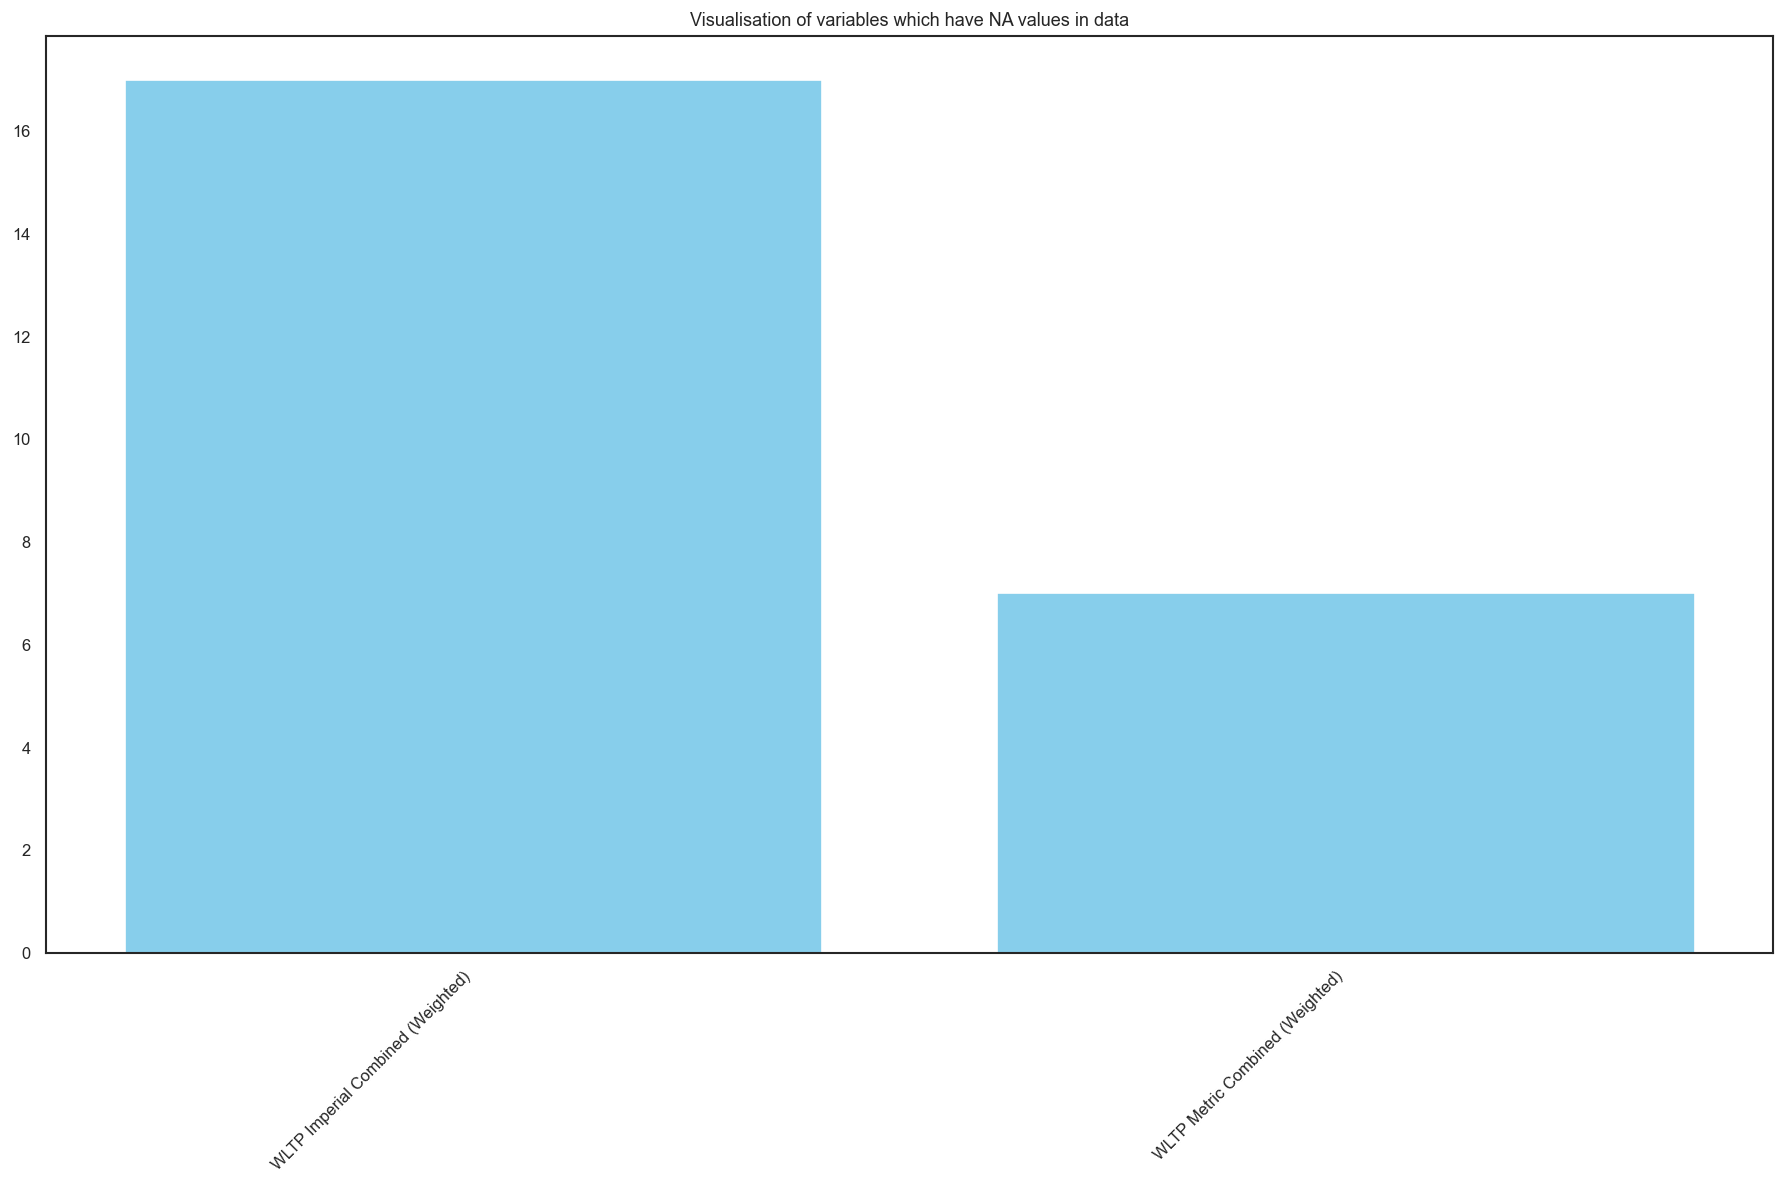

In [1267]:
# this function count and visualise any columns that has NA values as bar chart 
def count_visualisa_na(data, data_name = "data"):
    NA_list = []
    col_name_list = []
    for i in range(data.shape[1]):
        col_name = data.columns[i]
        count = data[col_name].isna().sum()
        if count != 0: 
            NA_list.append(count)
            col_name_list.append(col_name)
                
    fig, axs = plt.subplots(1, 1, figsize=(15, 10), dpi=120, sharey=True)
    axs.bar(col_name_list, NA_list, color = "skyblue")
    plt.xticks(rotation = 45, ha = "right")
    plt.title(f'Visualisation of variables which have NA values in {data_name}')
    fig.tight_layout()
    plt.show()
    
#Check and remove NA values in fuel dataset
print("Dataset shape before removing NA values:", data_fuel.shape)
count_visualisa_na(data_fuel)

In [1268]:
data_fuel = data_fuel.dropna()
print("Dataset shape after removing NA values:", data_fuel.shape)


Dataset shape after removing NA values: (1233, 19)


Dataset shape before removing NA values: (1686, 19)


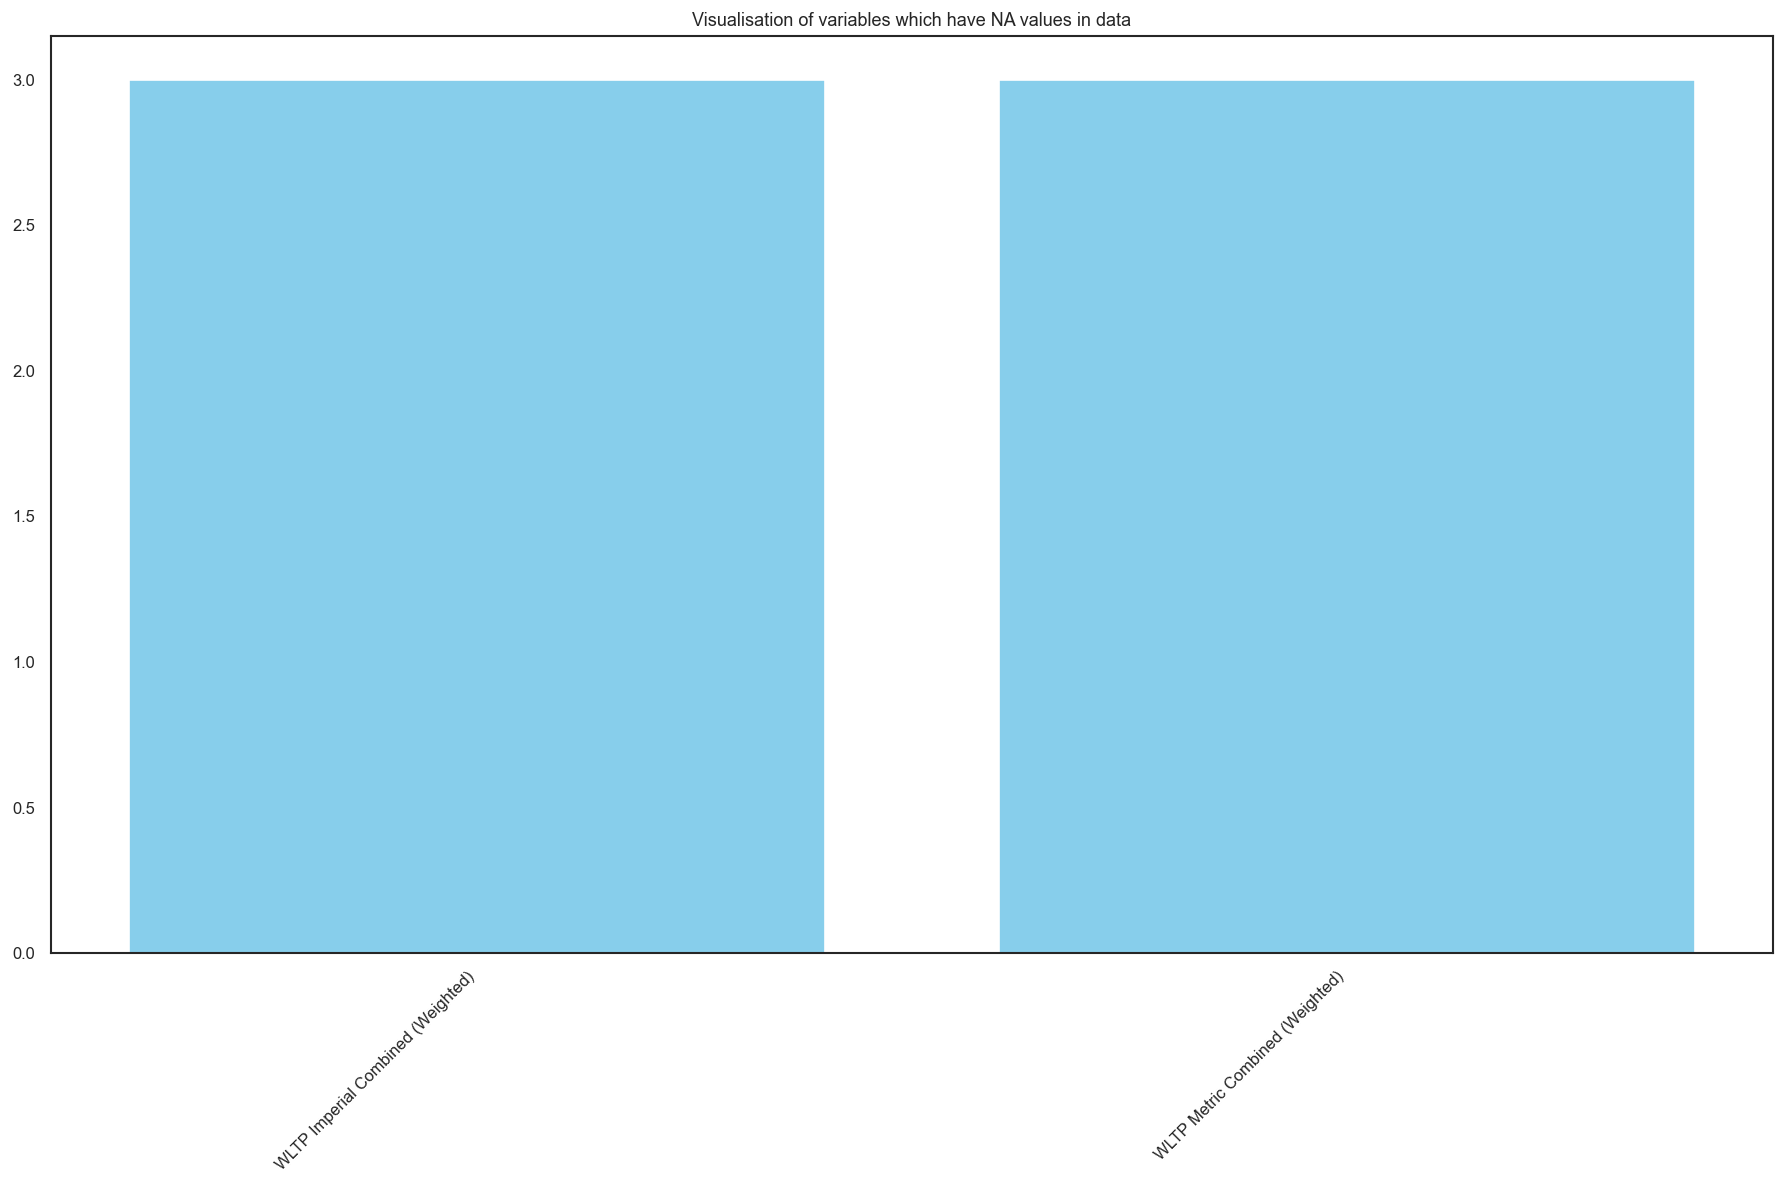

In [1269]:
#Check and remove NA values in fuel dataset
print("Dataset shape before removing NA values:", data_hybrid.shape)
count_visualisa_na(data_hybrid)

In [1270]:
data_hybrid = data_hybrid.dropna()
print("Dataset shape after removing NA values:", data_hybrid.shape)

Dataset shape after removing NA values: (1683, 19)


### Statistical Analysis

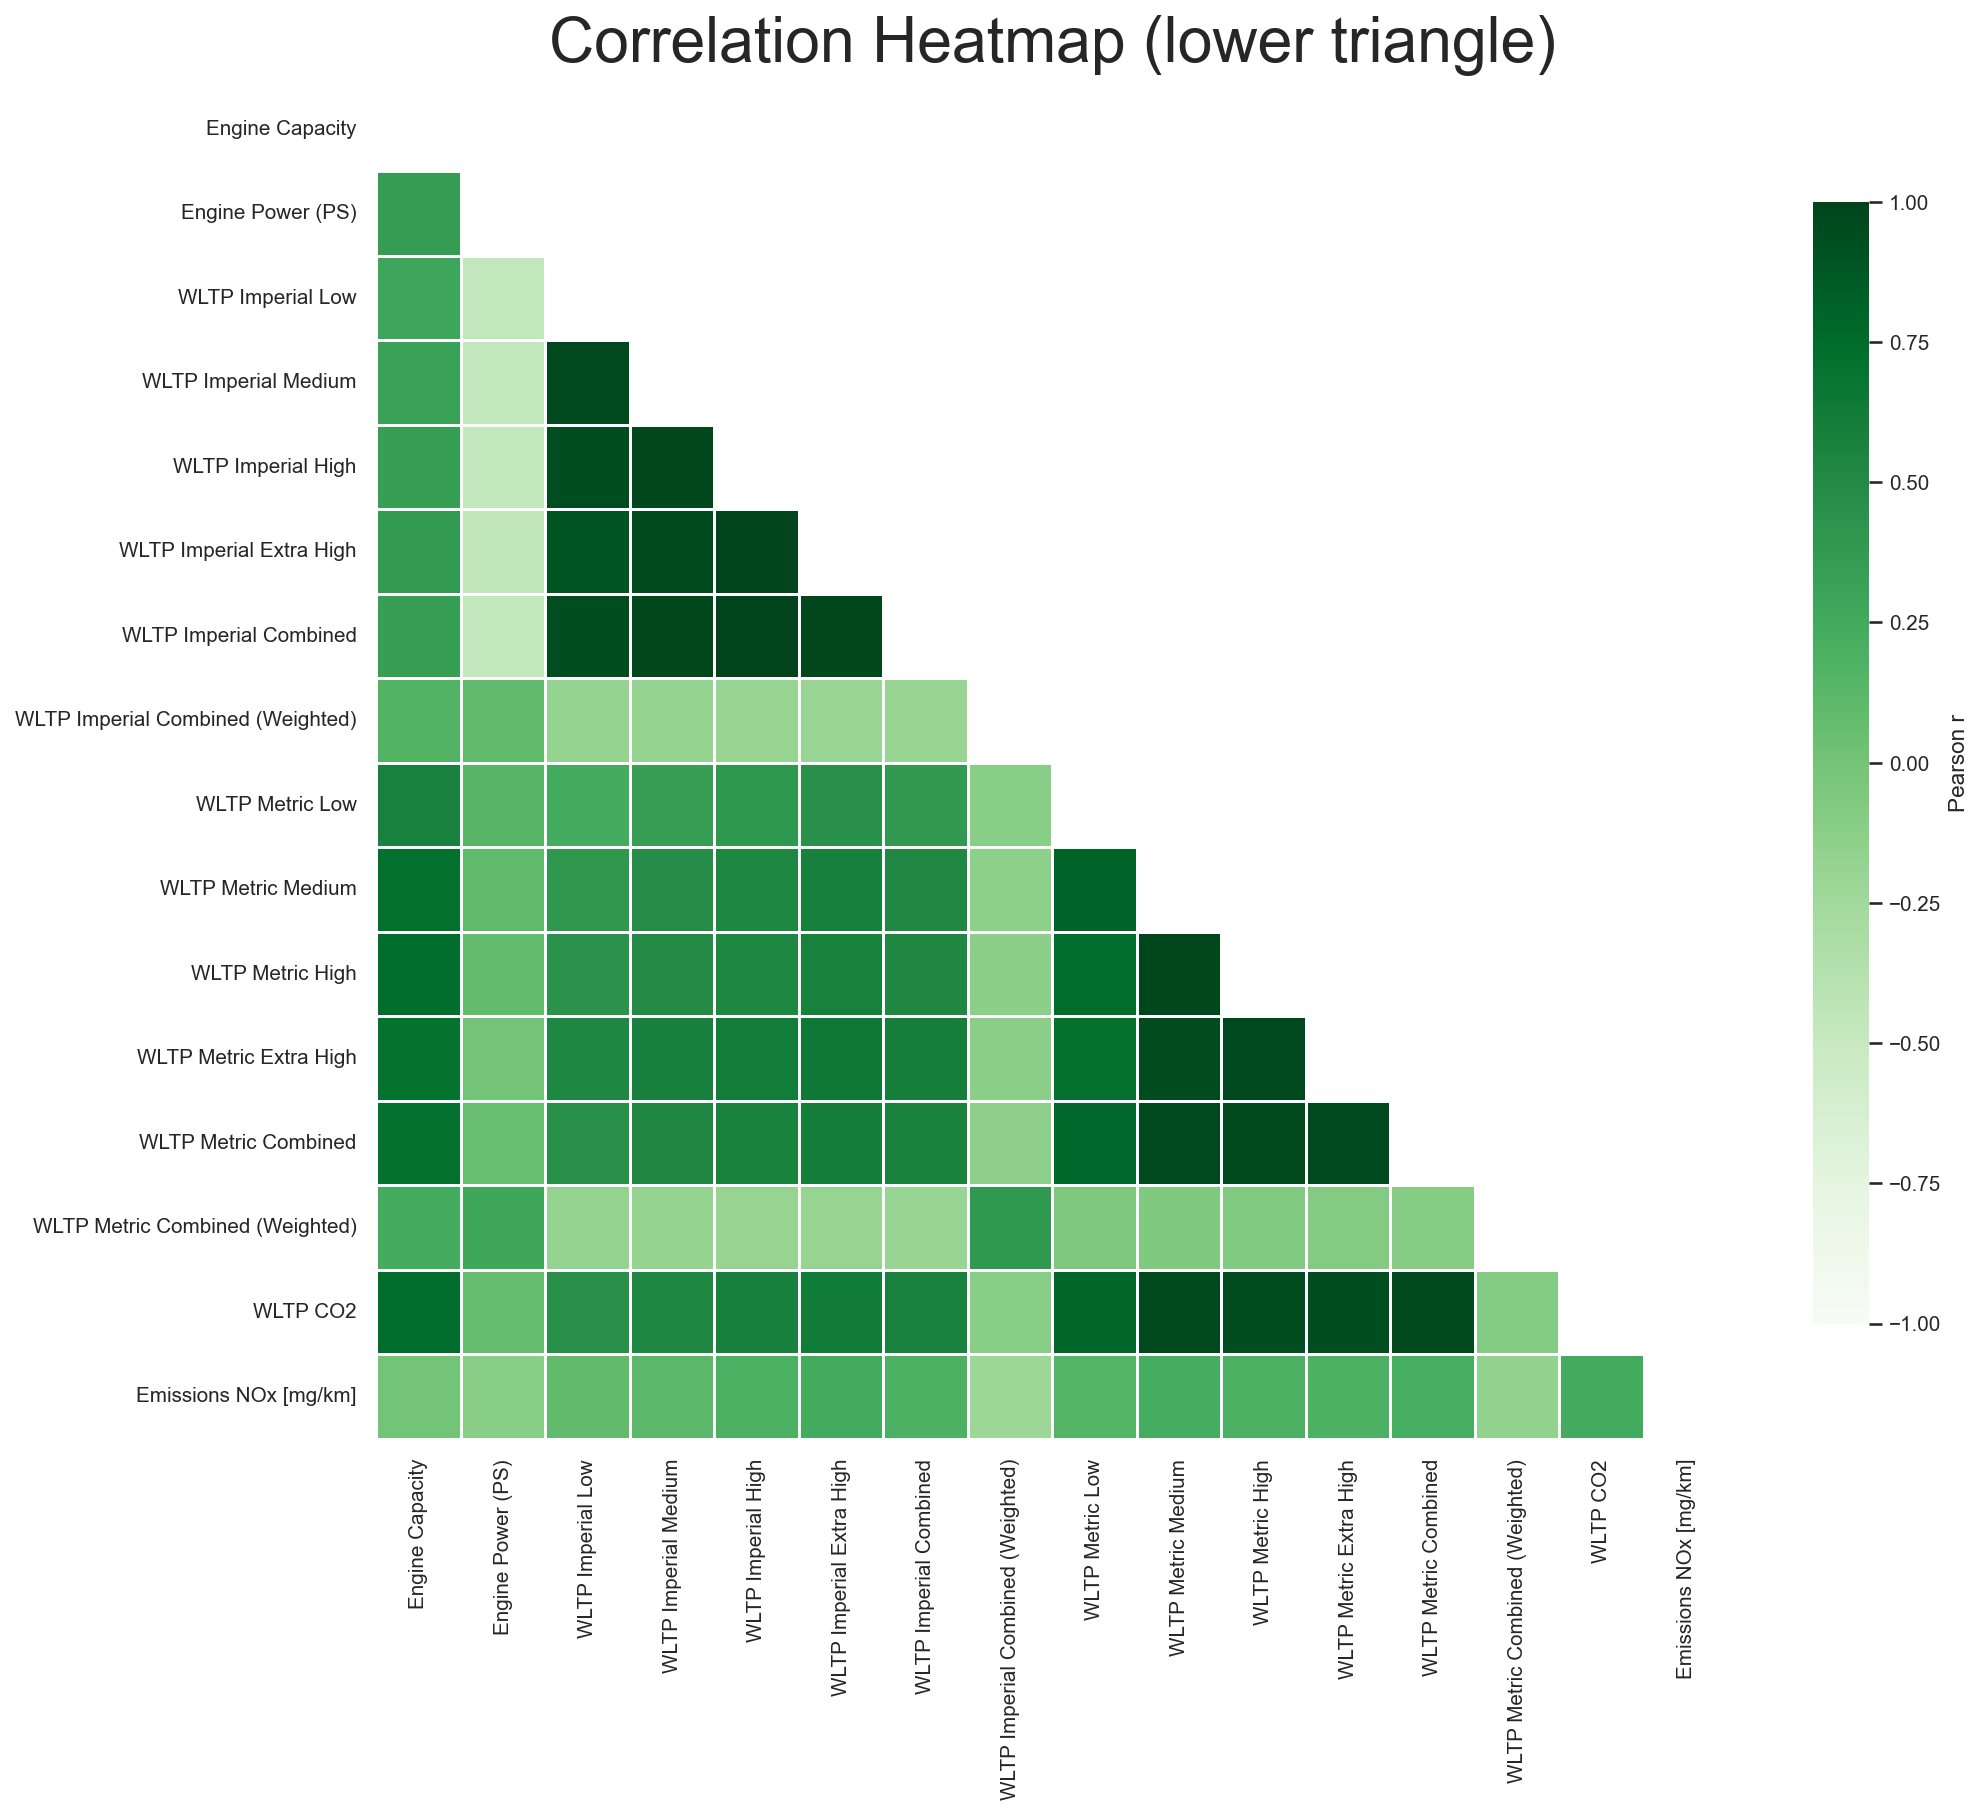

In [1271]:
sns.set_theme(style="white", font_scale=0.9)  # smaller fonts

# Select only numeric columns for computing correlation
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()

# mask the upper triangle (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12), dpi=150)
ax = sns.heatmap(
    corr, mask=mask, cmap="Greens", vmin=-1, vmax=1, center=0,
    linewidths=.5, linecolor="white",
    cbar_kws=dict(shrink=.8, label="Pearson r"),
    annot=False,  # turn off numbers (too dense)
    square=True
)

ax.set_title("Correlation Heatmap (lower triangle)", fontsize = 30, pad=12)
plt.tight_layout()
plt.show()

Since it is over detailed to visualise the correlation matrix of all variables, only top 20 will be visualised to examine their correlations.

In [1272]:
# Create a function to plot top Correlation values based on the target variable
def plot_top20_correlation(variable:str, data):
    # Set the target variable 
    target = variable

    # numeric-only correlation
    corr = data.select_dtypes(include='number').corr()

    # Extract correlations with target
    target_corr = corr[target].drop(labels=[target])

    # Sort by absolute correlation and take top 20
    top20 = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).head(20)

    # Plot
    plt.figure(figsize=(8, 7), dpi=150)
    bars = plt.barh(top20.index, top20.values, color='seagreen', edgecolor='black')

    # Add correlation values on bars
    for bar, value in zip(bars, top20.values):
        plt.text(value, bar.get_y() + bar.get_height()/2, f"{value:.2f}",
                ha='left' if value > 0 else 'right', va='center', fontsize=9)


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f"Top 20 Correlations with {target} from {data_label}", fontsize=15, pad=10)
    plt.xlabel("Correlation - Pearson r", fontsize=11)
    plt.ylabel("Variable", fontsize=11)
    plt.gca().invert_yaxis()  # highest correlation on top
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

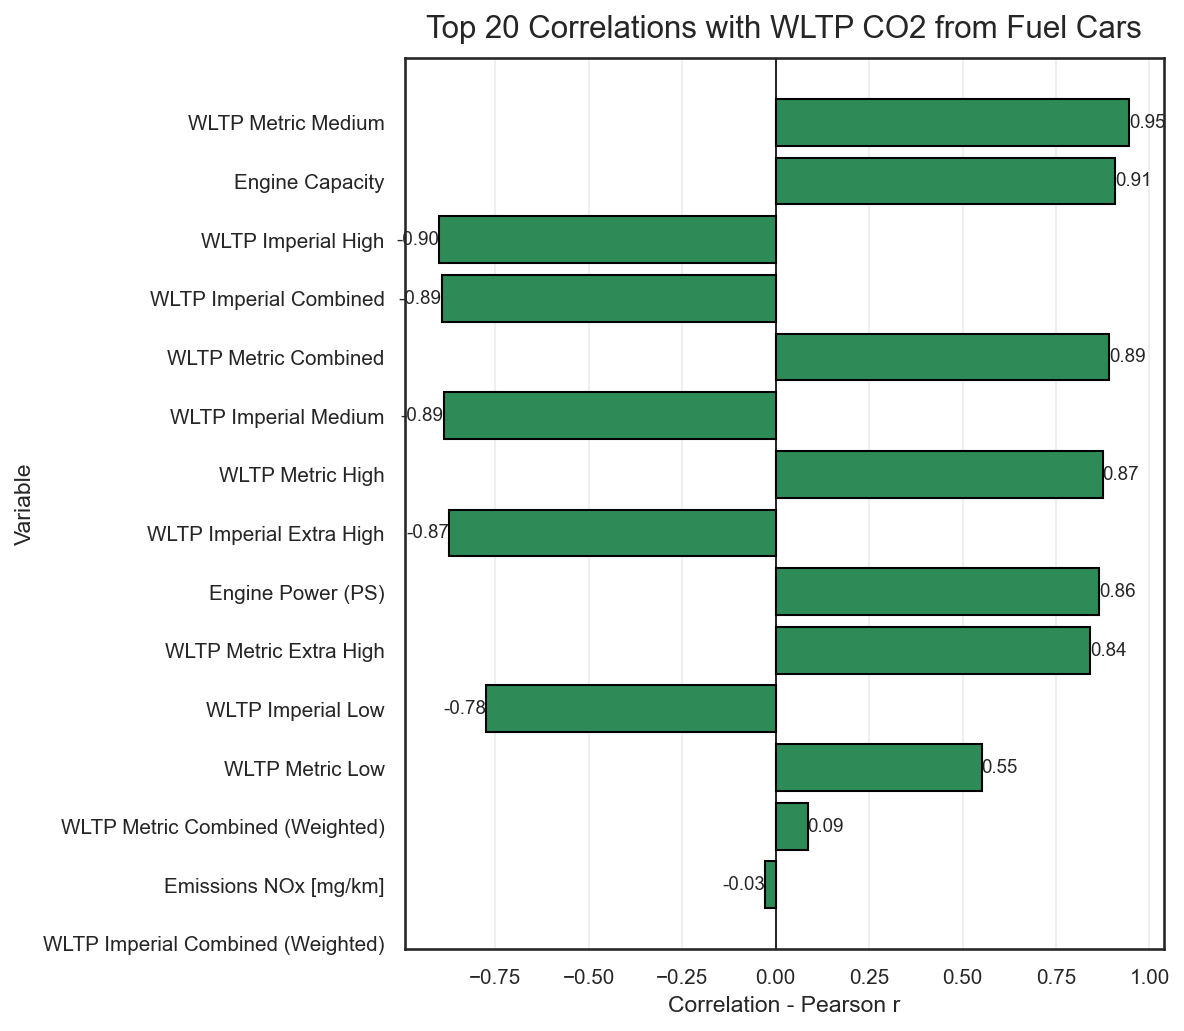

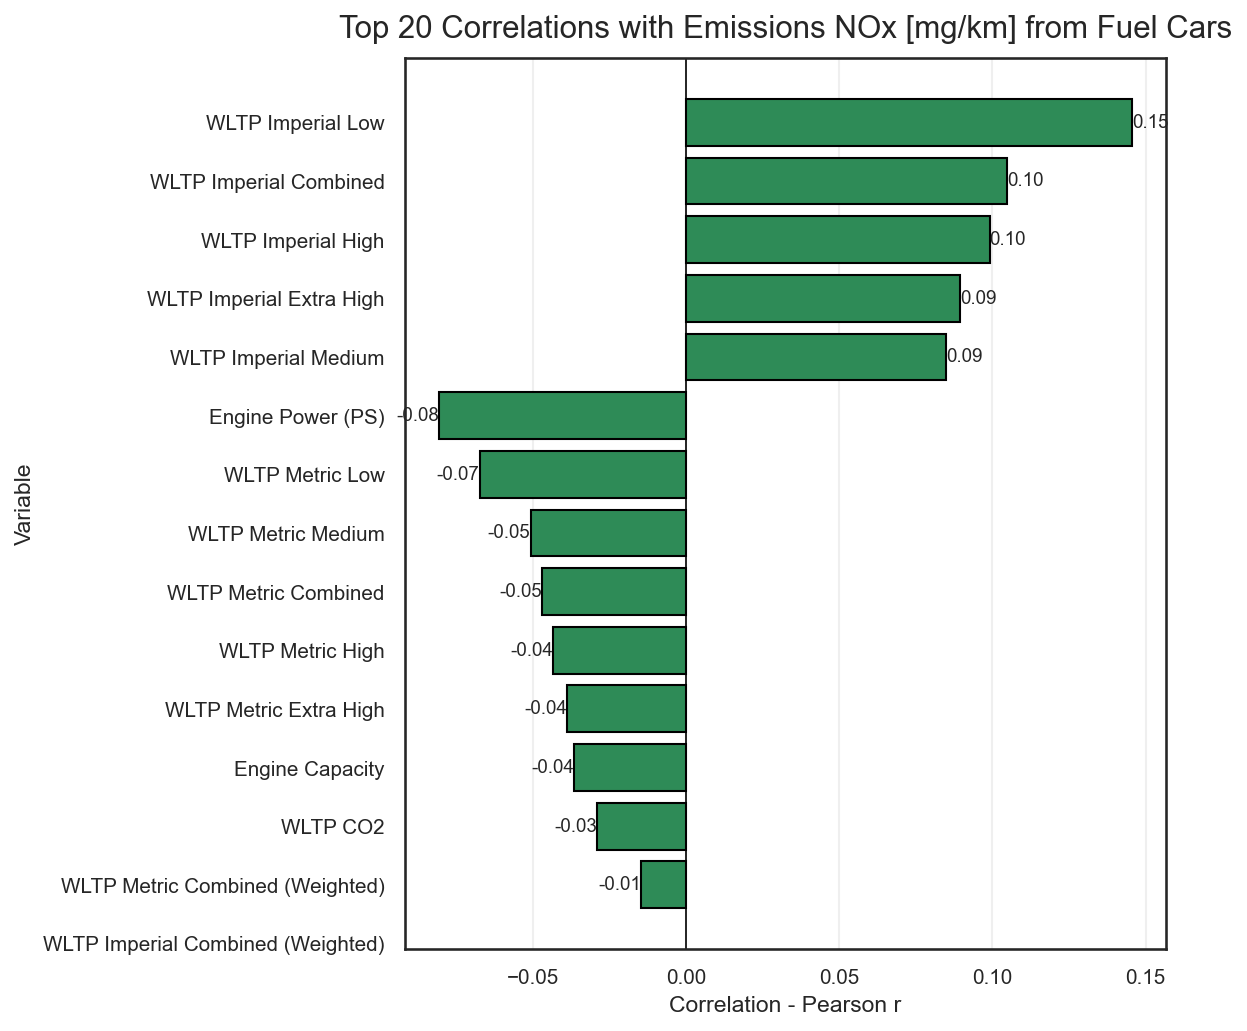

In [1273]:
# -- Correlation Matrix for Fuel Cars
plot_top20_correlation("WLTP CO2", data_fuel)
plot_top20_correlation("Emissions NOx [mg/km]", data_fuel)

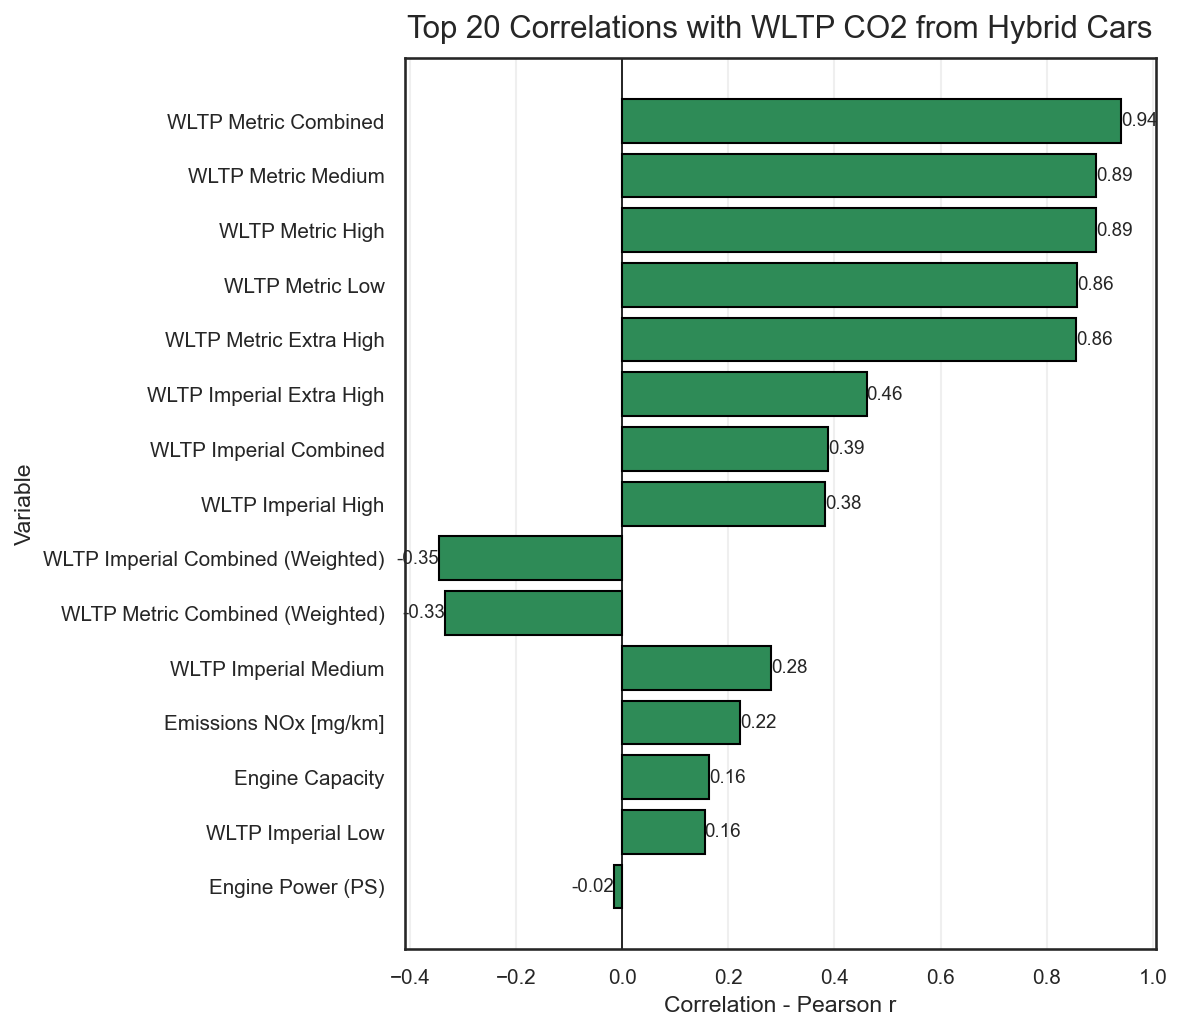

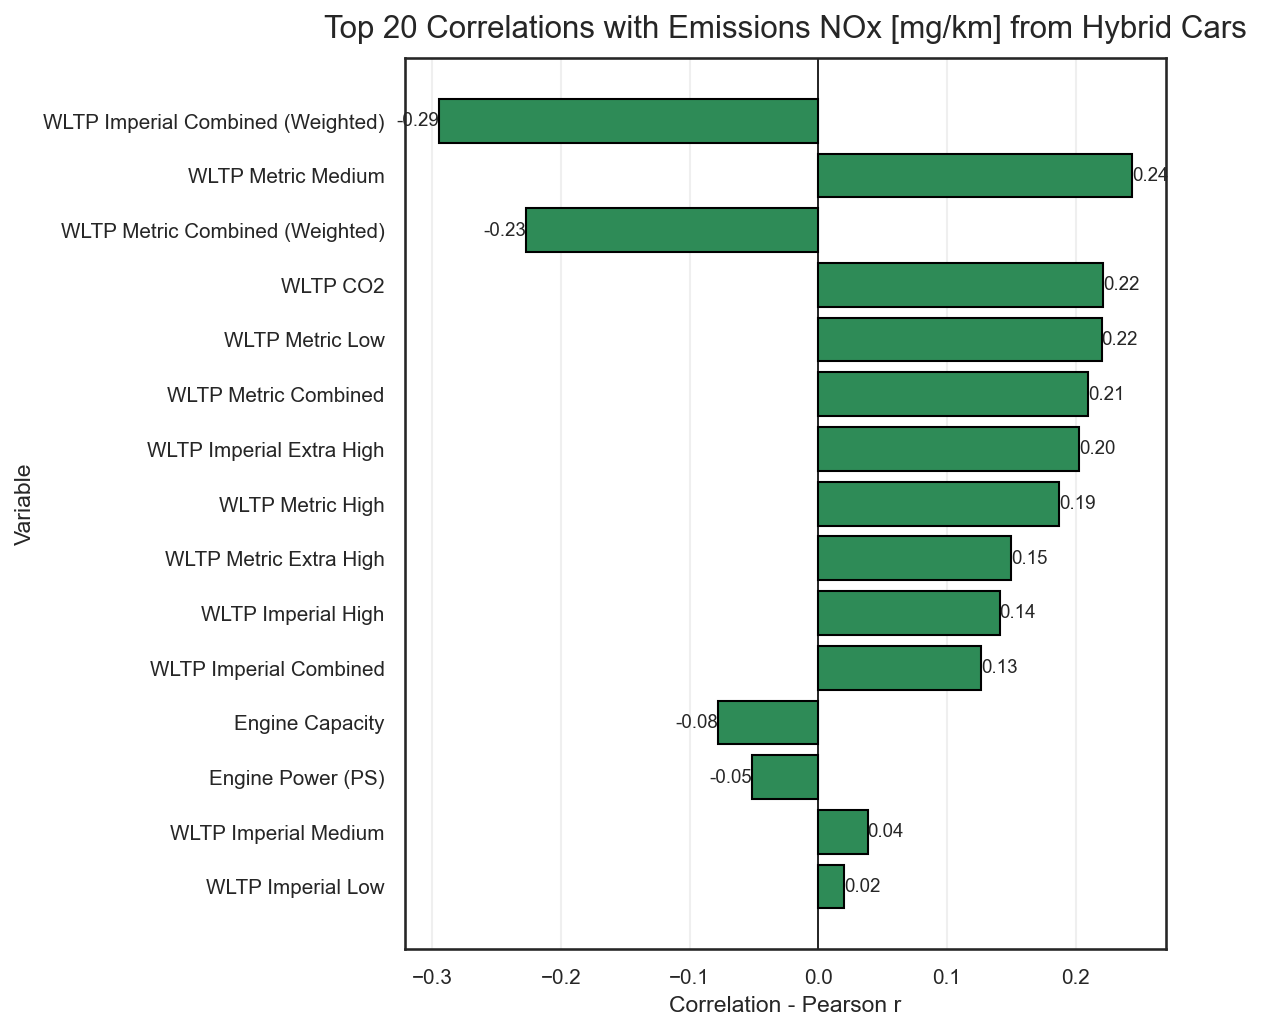

In [1274]:
# -- Correlation Matrix for Hybrid Cars
plot_top20_correlation("WLTP CO2", data_hybrid)
plot_top20_correlation("Emissions NOx [mg/km]", data_hybrid)

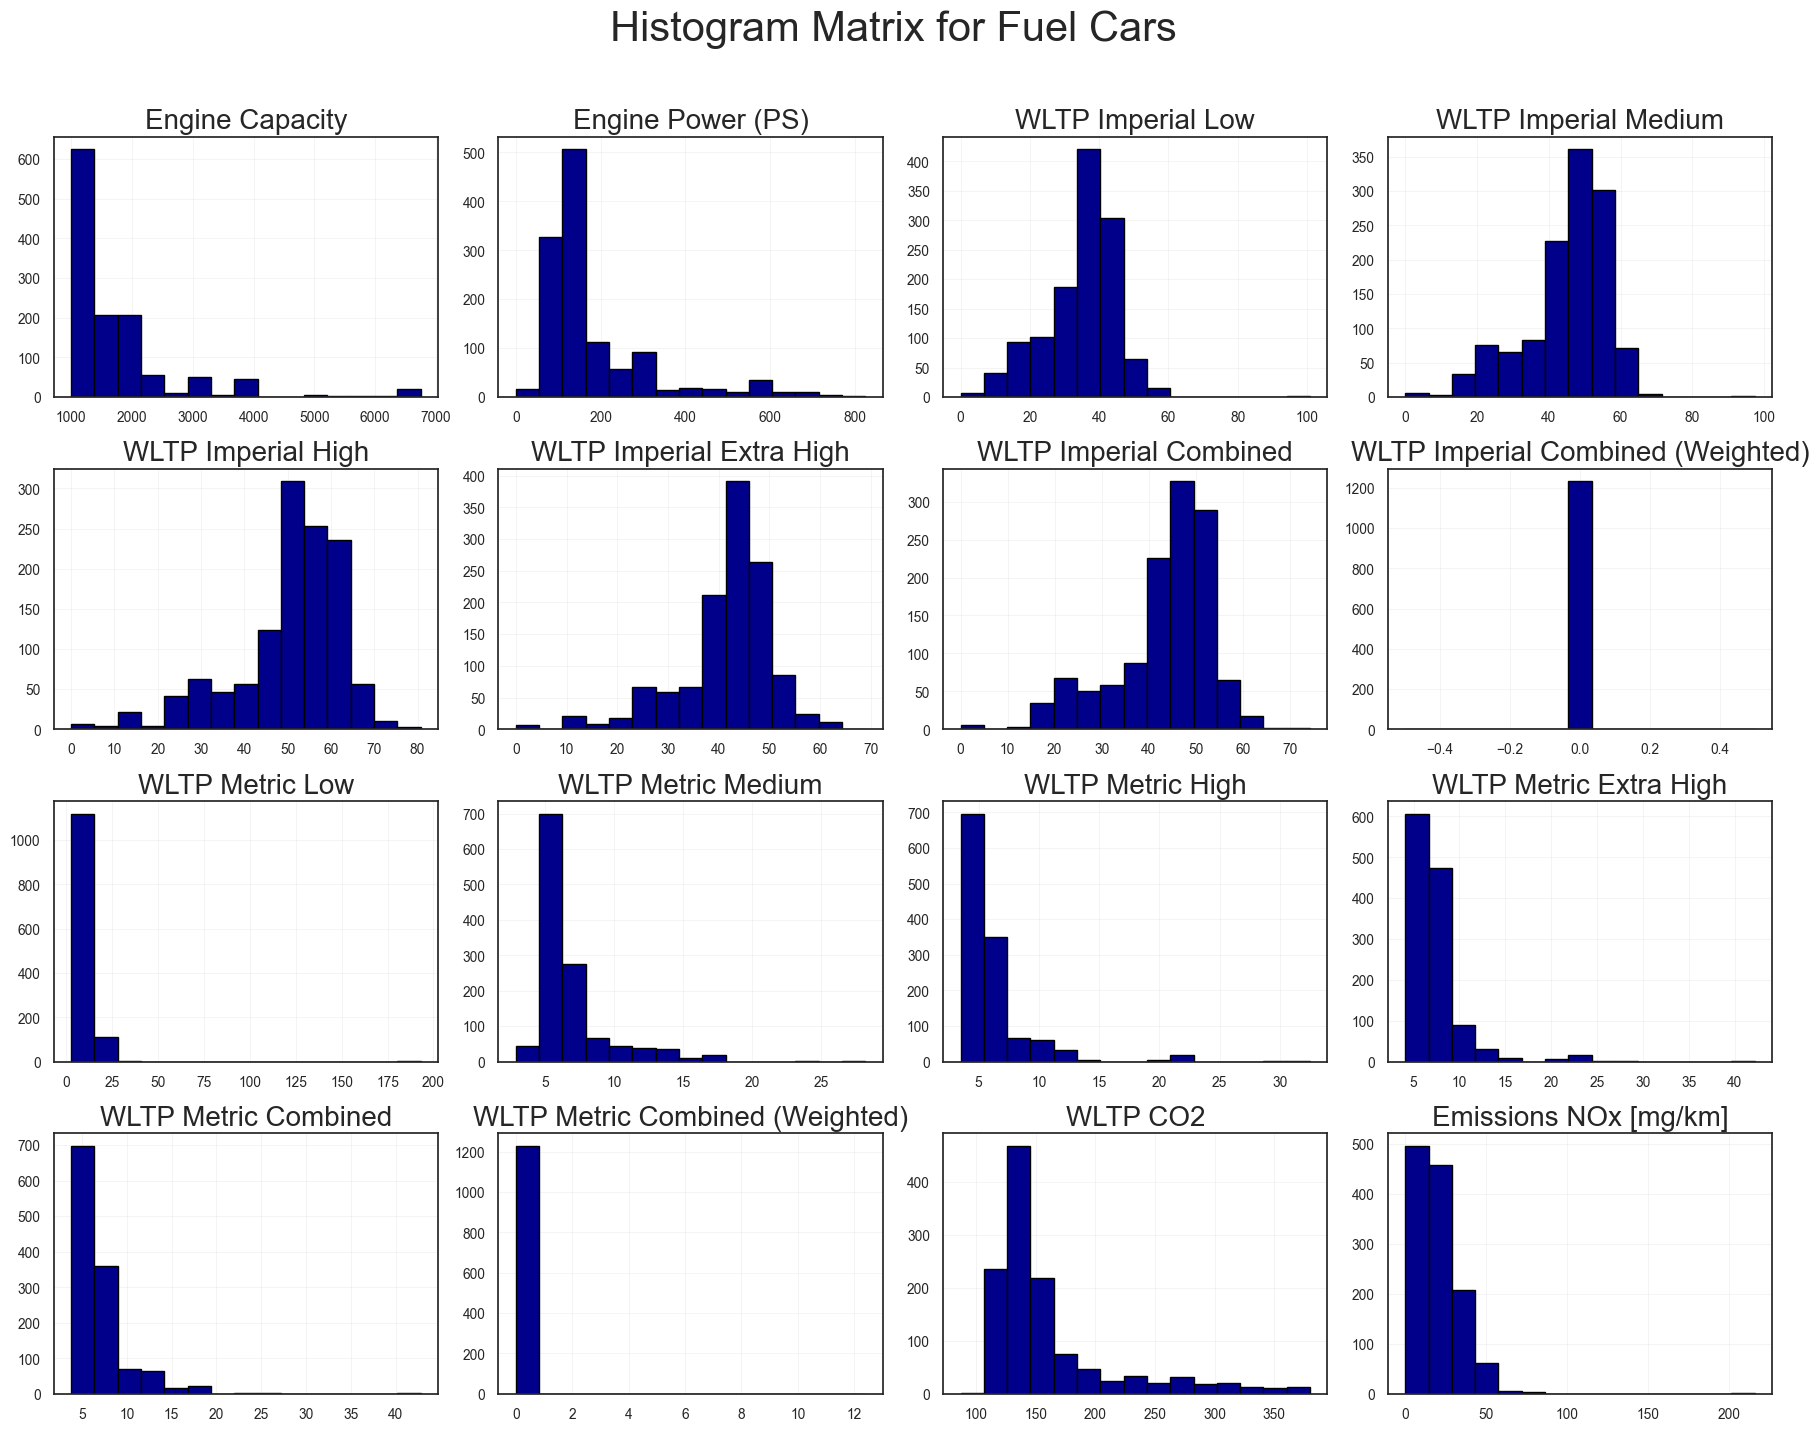

In [1275]:
# -- Histogram Matrix for Fuel Cars --

# Set overall figure size (width, height)
axes = data_fuel.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='darkblue',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Fuel Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

Remove WLTP Imperial Combined (Weighted) and WLTP Metric Combined (Weighted) due to their unsual distribution.

In [1276]:
# Remove irrelevant columns for regression task
data_fuel = data_fuel.drop(columns=["WLTP Imperial Combined (Weighted)", "WLTP Metric Combined (Weighted)"])
data_fuel.shape

(1233, 17)

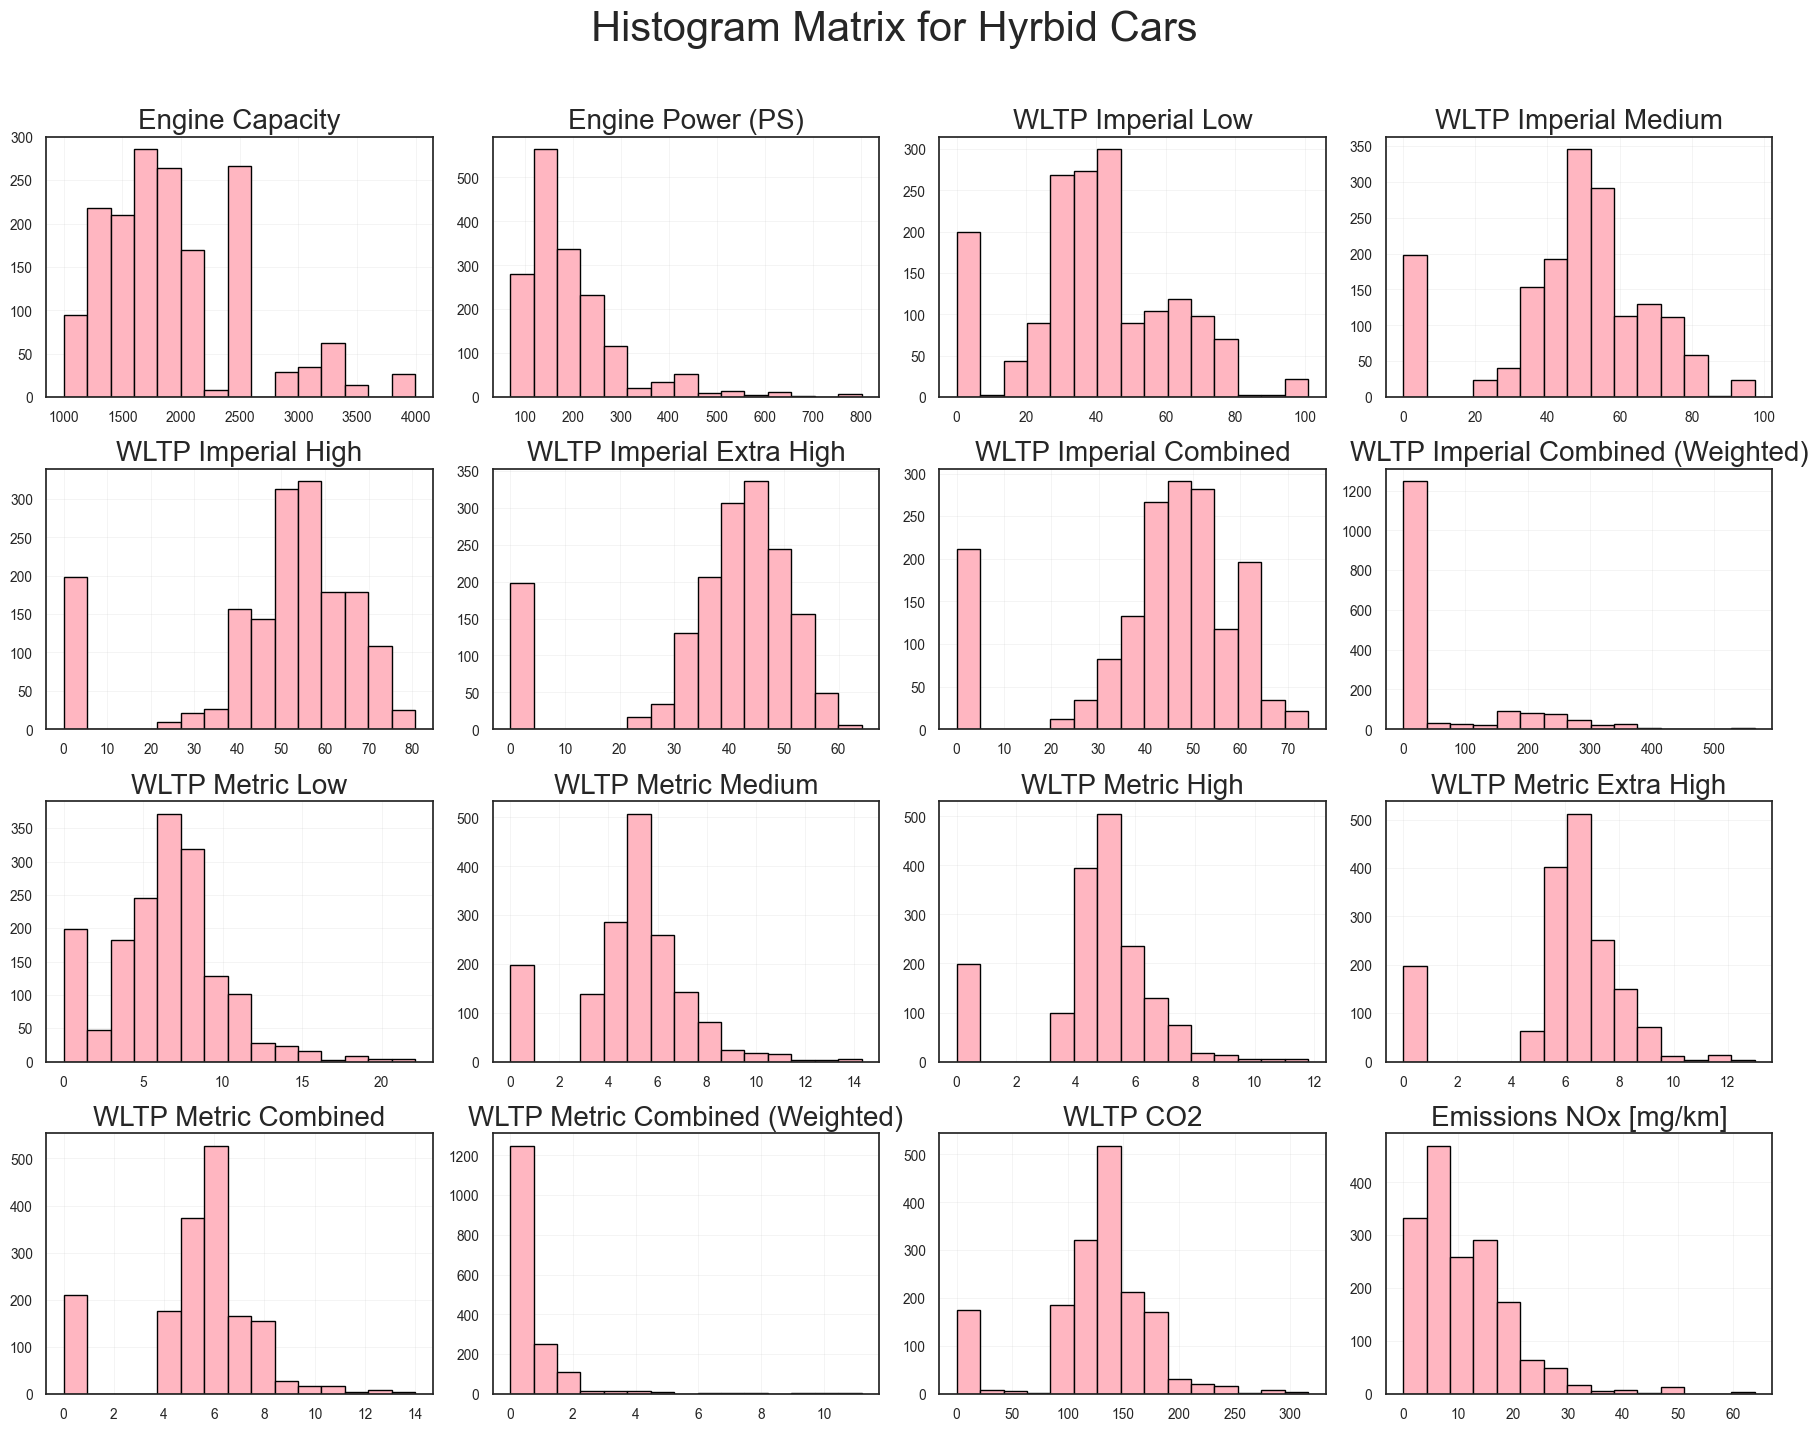

In [1277]:
# -- Histogram Matrix for Hyrbid Cars --

# Set overall figure size (width, height)
axes = data_hybrid.hist(
    figsize=(18, 14),  # larger matrix
    bins=15, # adjust bin count
    color='lightpink',
    edgecolor='black',
    grid=False
)

# Loop over all subplots to format text and labels
for ax in axes.flatten():
    # Bigger titles and smaller axis labels
    ax.set_title(ax.get_title(), fontsize=20)
    ax.set_xlabel(ax.get_xlabel(), fontsize=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)

    ax.grid(alpha=0.3, linewidth=0.5) # thin gridlines for readability

plt.suptitle("Histogram Matrix for Hyrbid Cars", fontsize=30, y=1.02)
plt.tight_layout()
plt.show()

### Outlier Check

Checking outliers on fuel car dataset

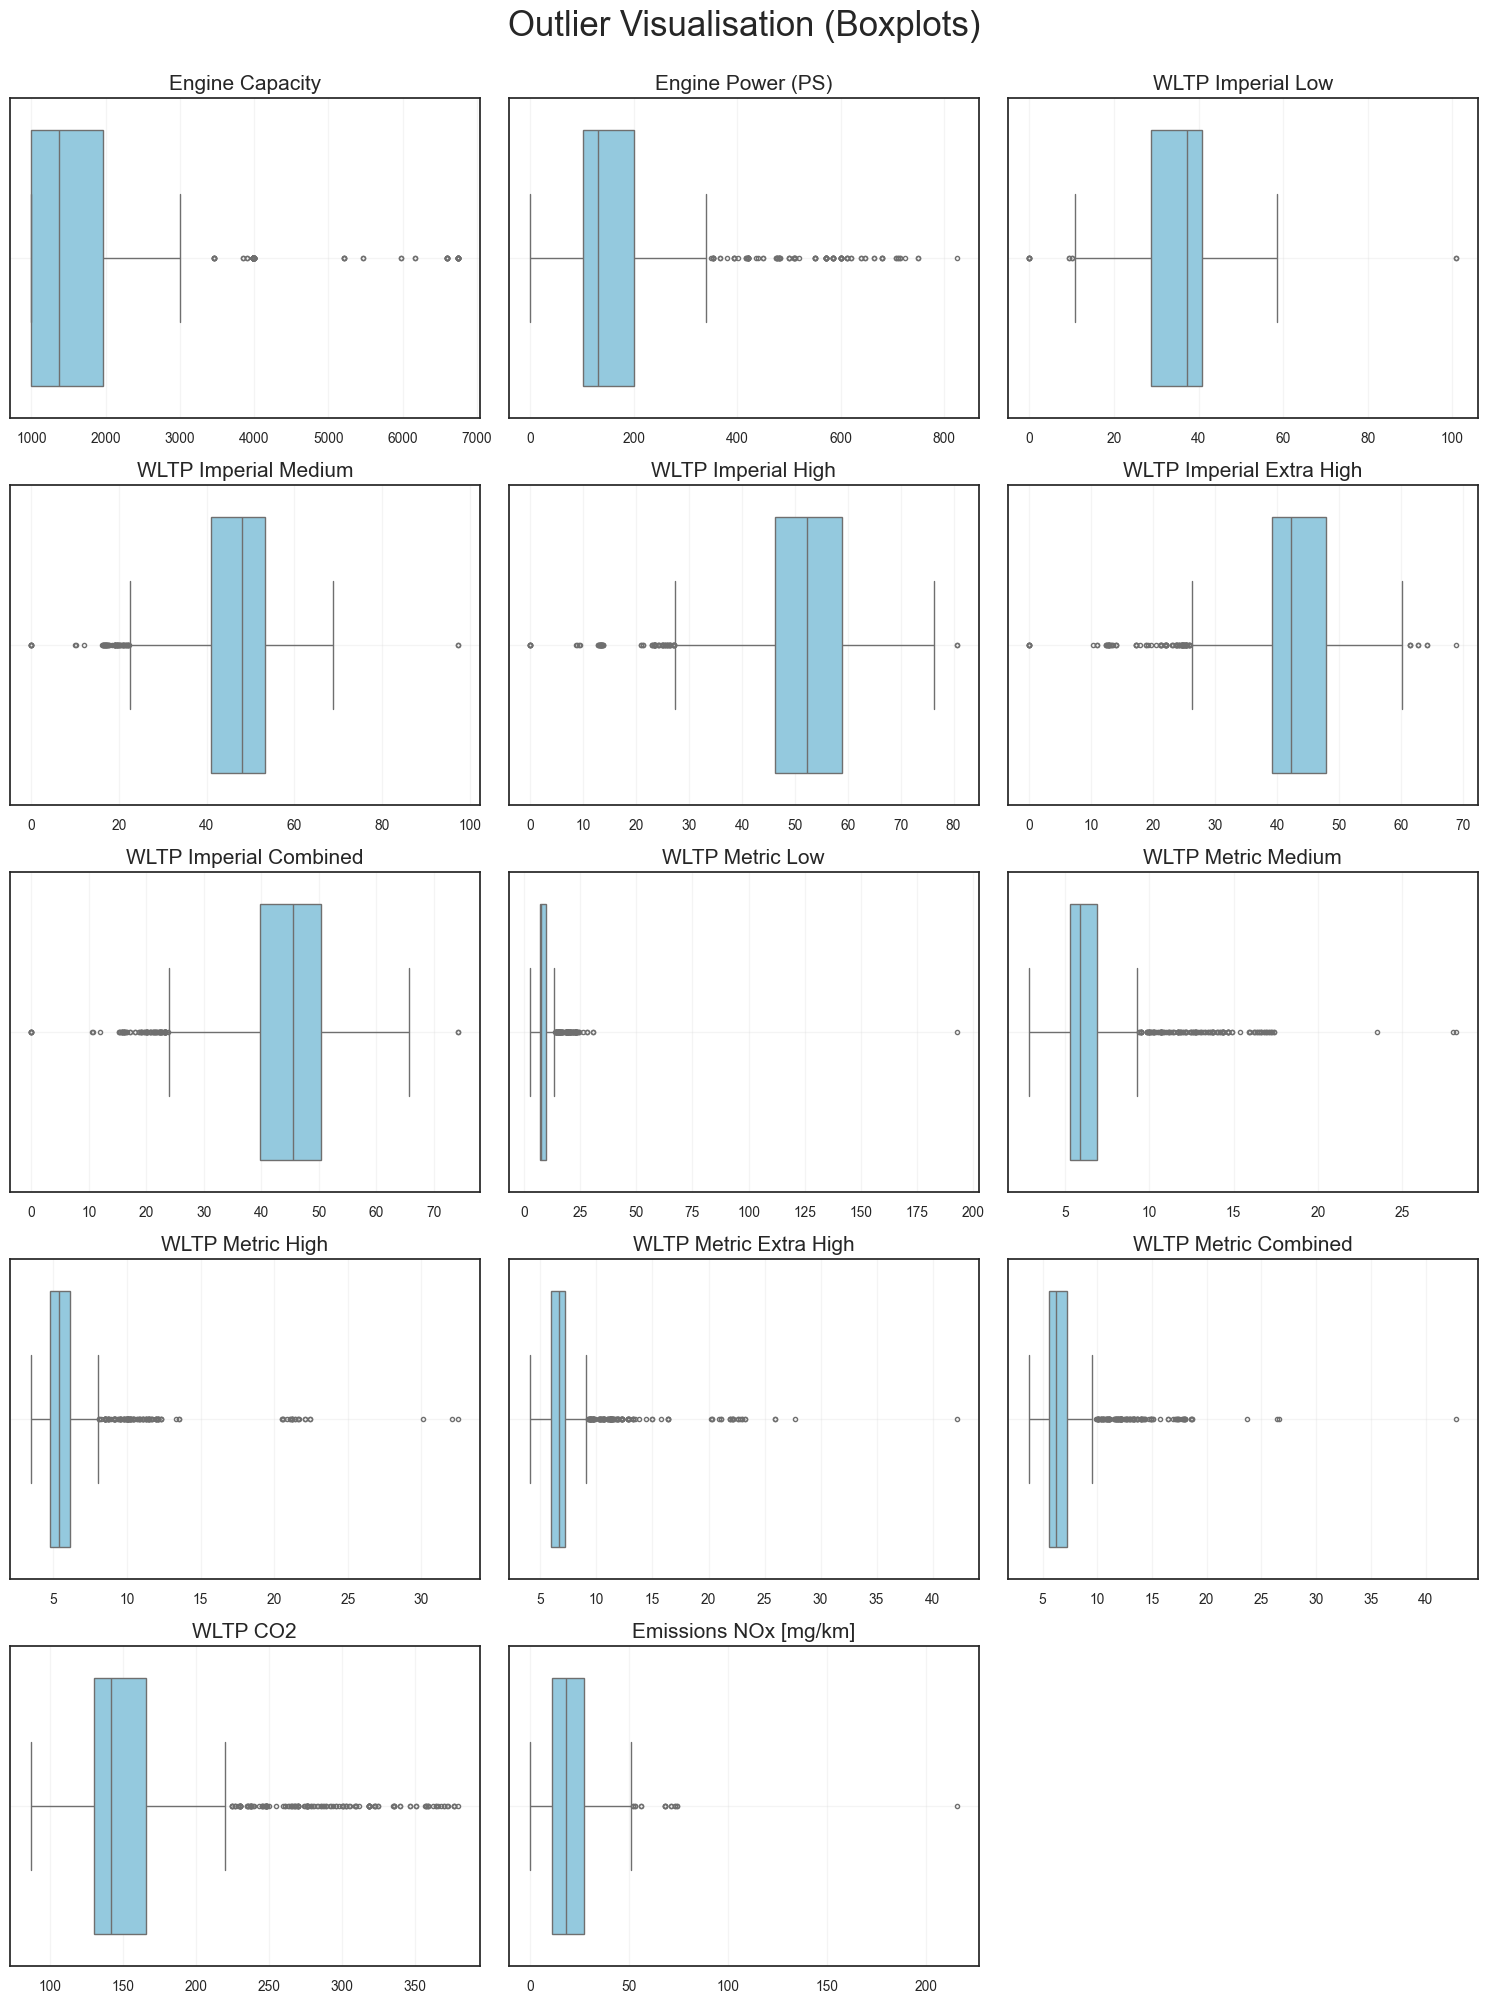

In [1278]:
# A reusable function to visualise outliers, arguments: dataset
def outlier_check(data):
    # Select only numeric columns
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric_cols) == 0:
        print("No numeric columns found in the dataset.")
        return
    
    # Determine layout
    n_cols = 3
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    
    # Set up figure
    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    plt.suptitle("Outlier Visualisation (Boxplots)", fontsize=25, y =1)
    
    # Create boxplots for each numeric column
    for idx, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, idx)
        sns.boxplot(x=data[col], color='skyblue', fliersize=3, linewidth=1)
        plt.title(col, fontsize=15)
        plt.xlabel("")
        plt.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

outlier_check(data_fuel)

The following variables should be removed from fuel car data since they have high amount of outliers: 

In [1279]:
removed_variables_fuel = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined" ]

print(f"Data shape before removing columns: {data_fuel.shape}")

data_fuel = data_fuel.drop(columns=removed_variables_fuel)
print(f"Data shape after removing columns: {data_fuel.shape}")

Data shape before removing columns: (1233, 17)
Data shape after removing columns: (1233, 12)


Checking outliers on hybrid car dataset

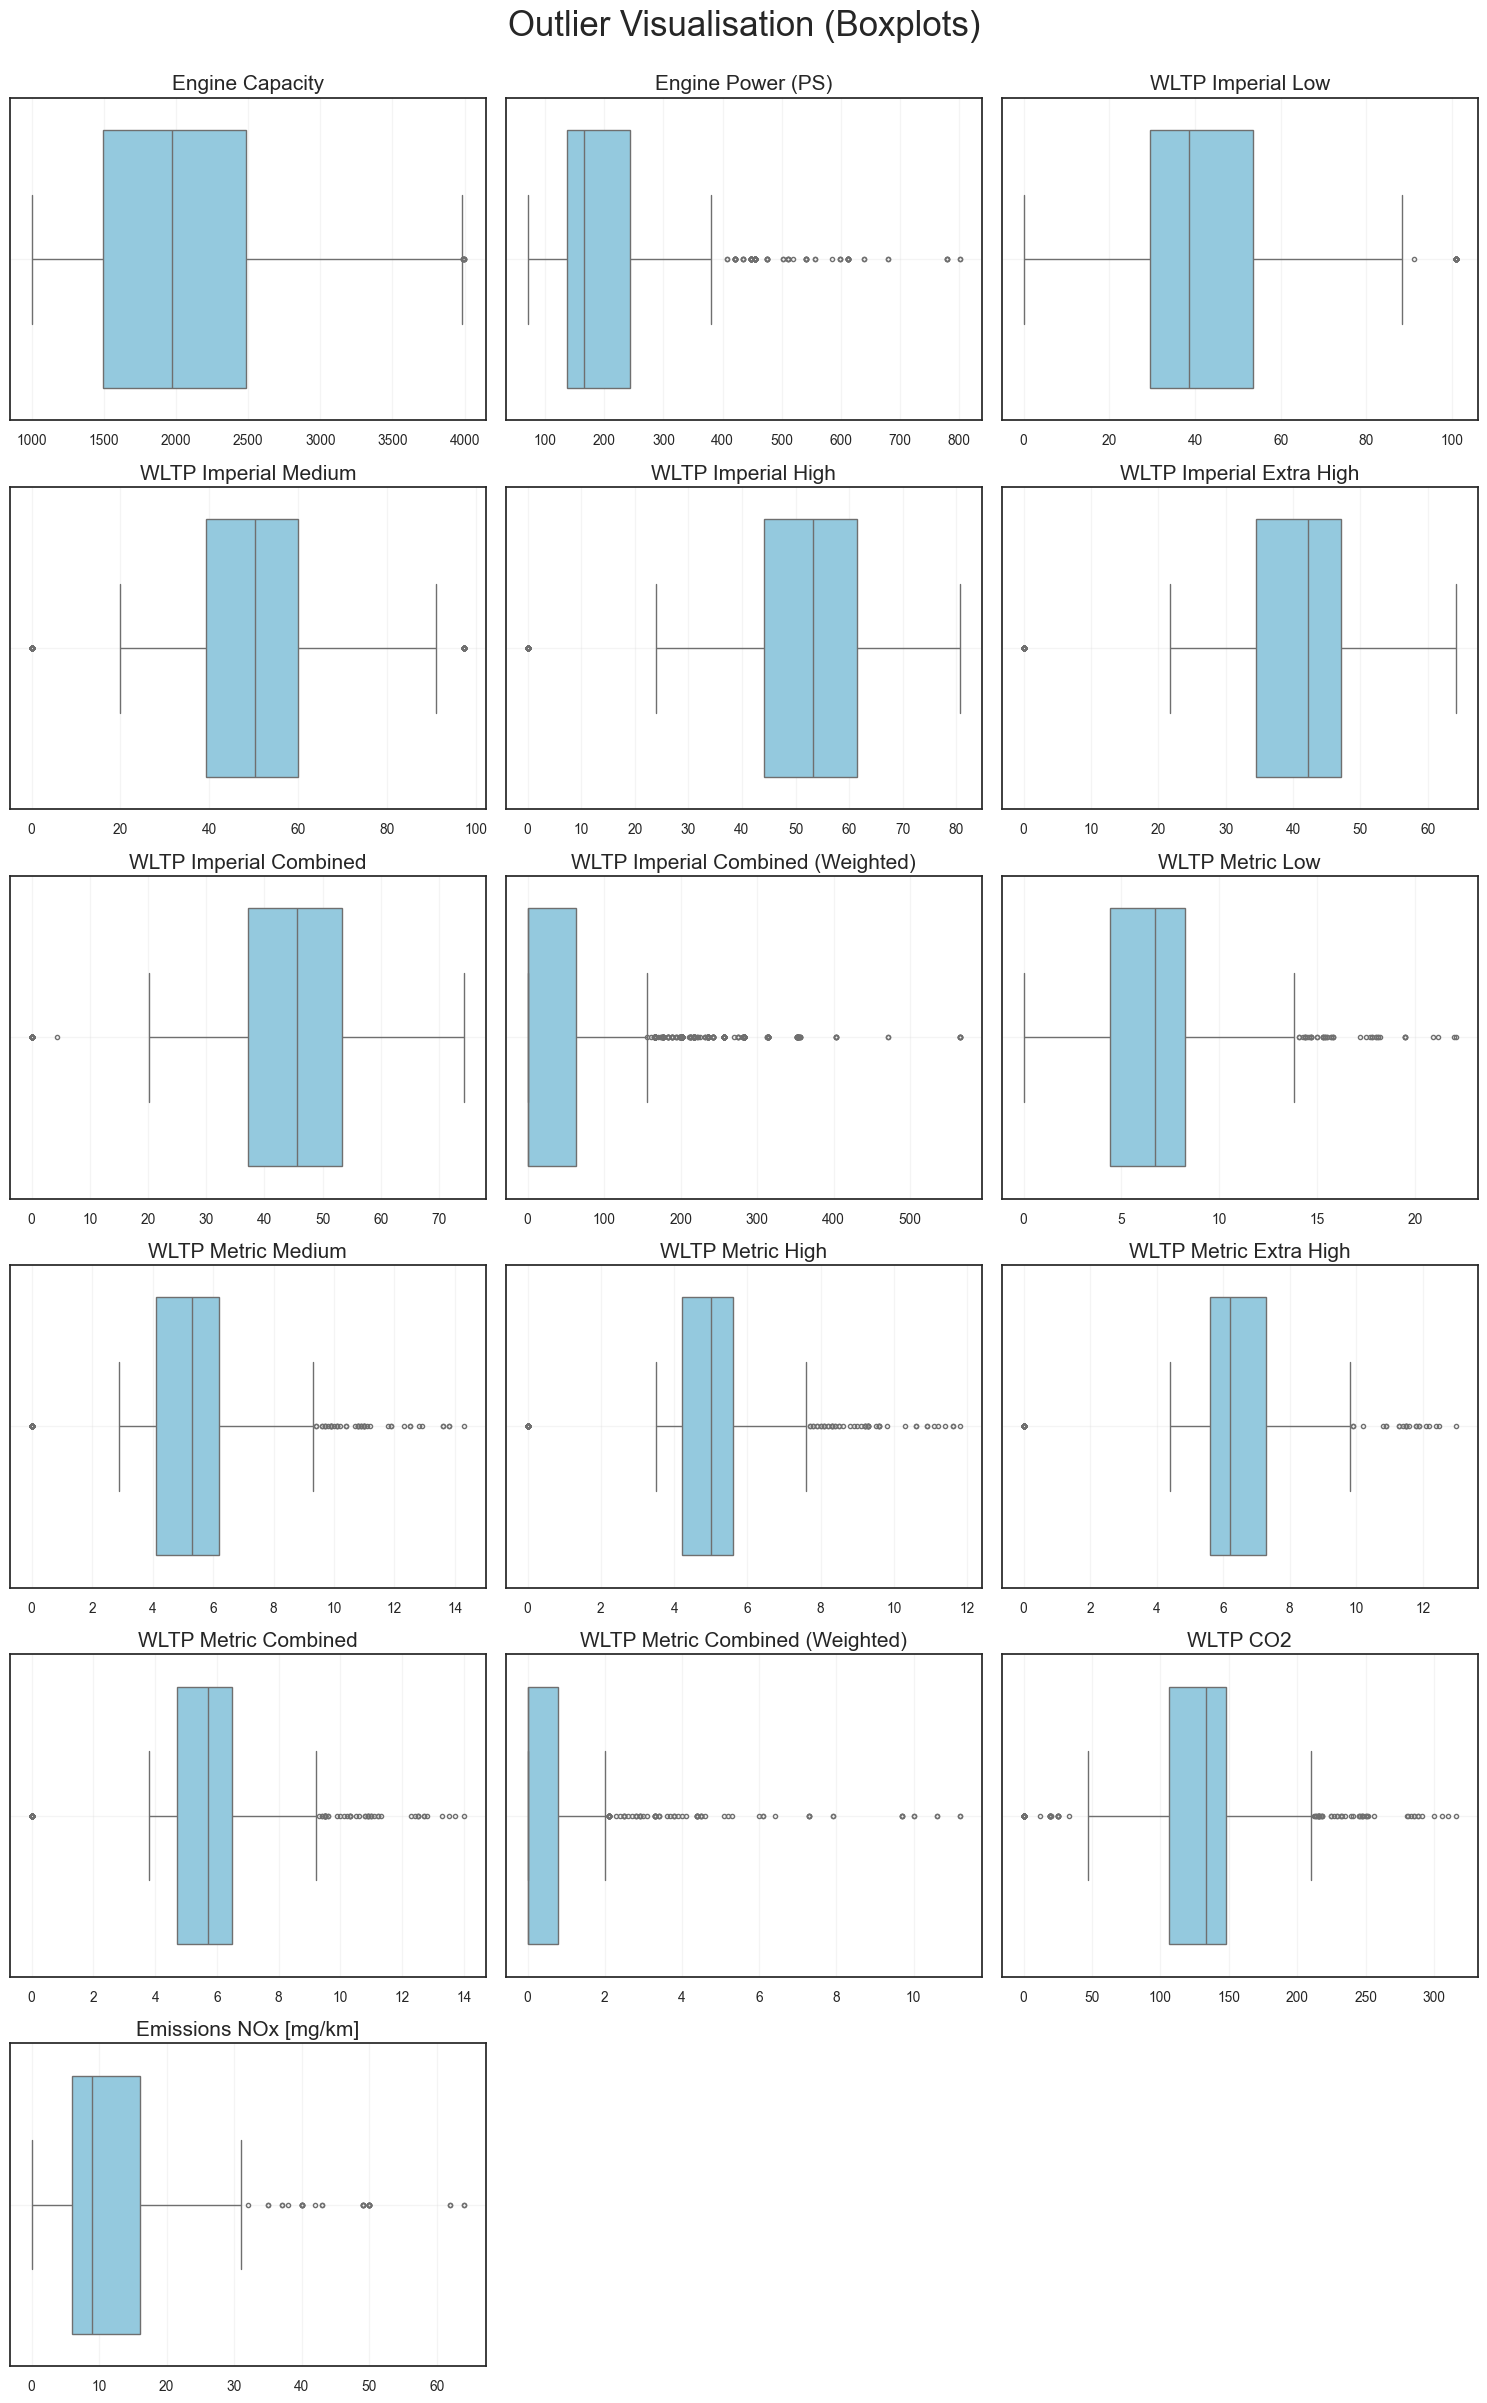

In [1280]:
outlier_check(data_hybrid)

The following variables should be removed from fuel car data since they have high amount of outliers: 

In [1281]:
removed_variables_hybrid = [ "WLTP Metric Low", "WLTP Metric Medium",
                            "WLTP Metric High", "WLTP Metric Extra High",
                            "WLTP Metric Combined", "WLTP Metric Combined (Weighted)",
                            "WLTP Imperial Combined (Weighted)" ]

print(f"Data shape before removing columns: {data_hybrid.shape}")

data_hybrid = data_hybrid.drop(columns=removed_variables_hybrid)
print(f"Data shape after removing columns: {data_hybrid.shape}")

Data shape before removing columns: (1683, 19)
Data shape after removing columns: (1683, 12)


Decide which variables to be removed for hybrid cars (comment here)

### The validation of datasets

In [1282]:
# Data Splitting Function into training set, test set, and validation set
np.random.seed(42) # for reproducibility

def data_split(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."
    
    # Split X/y
    X = data.drop(columns=[target])
    y = data[target]
    
    # Simple numeric imputation (if there are any remaining NaNs)
    # X = X.fillna(X.mean(numeric_only=True)).fillna(0)
    
    # 80 / 20 split, then 10 / 10 from the 20
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, 
                                                         random_state=random_state)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, 
                                                     random_state=random_state)
     
    # Encode categorical variables as dummy/one-hot columns
    X_train = pd.get_dummies(X_train, drop_first=True, dtype=float)
    X_val   = pd.get_dummies(X_val,   drop_first=True, dtype=float)
    X_test  = pd.get_dummies(X_test,  drop_first=True, dtype=float)

    #Re-index columns after encoding
    train_cols = X_train.columns
    X_val  = X_val.reindex(columns=train_cols, fill_value=0)
    X_test = X_test.reindex(columns=train_cols, fill_value=0)
    
    #Scaling the X data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return {
         "X_train": X_train,
         "X_val": X_val,
         "X_test": X_test,
         "y_train": y_train,
         "y_val": y_val,
         "y_test": y_test
    }     

#reuse this part to access the splitted data.
splits = data_split("WLTP CO2", data_fuel)

# Access the data 
X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(X_train[0:5,:])

(986, 13)
(124, 13)
(123, 13)
[[-0.69355105 -0.66468299  0.23878138  0.22261852  0.16192353  0.0135079
   0.15199583 -1.26703709 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [ 3.44051473  3.98740879 -2.37420157 -2.1867223  -2.14748521 -2.05174708
  -2.26179734  0.2015991   1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69355105 -0.50040367  0.59553551  0.43249142  0.31956235  0.087267
   0.29071957 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.20296869 -0.23158296 -0.03119472 -0.14675777 -0.18488188 -0.16562136
  -0.08845866 -1.26703709  1.04142527  0.5139091  -0.19466571  0.12428995
  -0.11558867]
 [-0.69453418 -0.81402783  1.51152584  1.47346097  1.34421469  0.86700613
   1.23404104 -0.62849962 -0.96022252  0.5139091  -0.19466571  0.12428995
  -0.11558867]]


*Fuel car data*


In [1283]:
# -- Reusable function for 10-fold CV and evaluation (regression task)--

np.random.seed(42) # for reproducibility

def tenfold_dataValidation(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    linear_model = LinearRegression()

    # 10-fold CV on TRAIN ONLY (neg MSE -> MSE) 
    mse_scores = -cross_val_score(linear_model, X_train, y_train, cv=10,
                              scoring="neg_mean_squared_error")
    
    print("10-fold CV MSE scores:", mse_scores.tolist())
    print("Mean MSE:", np.mean(mse_scores))

    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    # --- Plot CV MSE ---
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), mse_scores, marker='o', linestyle='-')
    plt.title(f'10-Fold Cross-Validation (MSE) of {target} from {data_label}')
    plt.xlabel('Fold Number'); plt.ylabel('Mean Squared Error (MSE)')
    plt.grid(alpha=0.3); plt.xticks(range(1, 11))

    # --- Fit on train, check validation ---
    linear_model.fit(X_train, y_train)
    val_pred  = linear_model.predict(X_val)
    test_pred = linear_model.predict(X_test)

    # MSE on validation and test
    print("Validation MSE:", mean_squared_error(y_val,  val_pred))
    print("Test MSE:",       mean_squared_error(y_test, test_pred))
    print("\n") #spacing for readability

    # RMSE on validation and test
    print("Validation RMSE:", np.sqrt(mean_squared_error(y_val,  val_pred)))
    print("Test RMSE:",  np.sqrt(mean_squared_error(y_test, test_pred))) 

    # return splitted datasets for further use in NN function
    # return {
    # "X_train": X_train,
    # "X_val": X_val,
    # "X_test": X_test,
    # "y_train": y_train,
    # "y_val": y_val,
    # "y_test": y_test
    # }

10-fold CV MSE scores: [226.8818560077228, 71.07971037711793, 240.4021221495773, 228.03641940795396, 185.59233512324136, 201.05651444852853, 392.8378576500156, 127.07826439321468, 237.20072334626278, 203.96008070823763]
Mean MSE: 211.41258836118723
Validation MSE: 936.3065519621466
Test MSE: 949.197496721195


Validation RMSE: 30.599126653585174
Test RMSE: 30.809048942172737


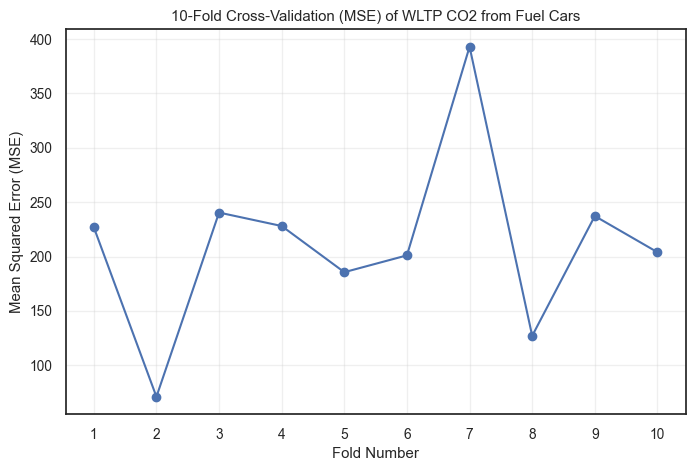

In [1284]:
# data validation for fuel cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_fuel)

10-fold CV MSE scores: [196.263888695339, 166.97656776826773, 171.84763097495428, 236.30575475101722, 164.63380342084642, 171.42723437305426, 193.74103894193985, 585.9913886695763, 154.96234536980253, 197.3585544035697]
Mean MSE: 223.95082073683676
Validation MSE: 1400.8457844798568
Test MSE: 1293.3702178748638


Validation RMSE: 37.42787443176351
Test RMSE: 35.96345670086322


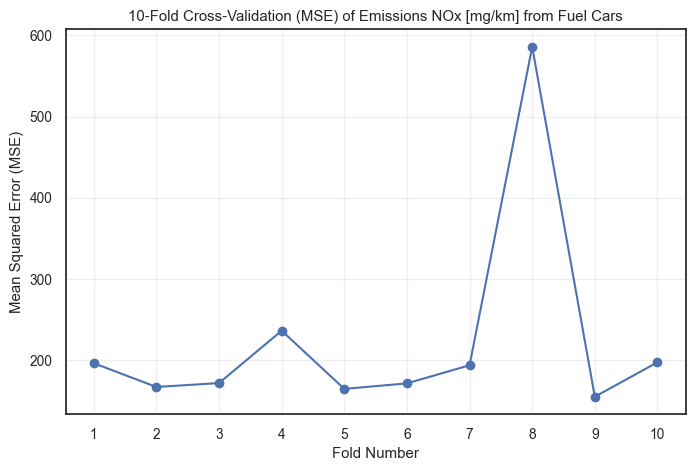

In [1285]:
# data validation for fuel cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_fuel)

*Hybrid car data*

10-fold CV MSE scores: [1239.2532655144914, 1586.0682053838518, 1366.9974995948303, 1170.7755565874538, 1552.5254169525424, 1825.9652911355797, 1507.1878461500476, 1271.4742172473284, 970.3356191917294, 1391.3434076879907]
Mean MSE: 1388.1926325445847
Validation MSE: 1036.097747870503
Test MSE: 1539.993103265366


Validation RMSE: 32.18847228233274
Test RMSE: 39.242745868062876


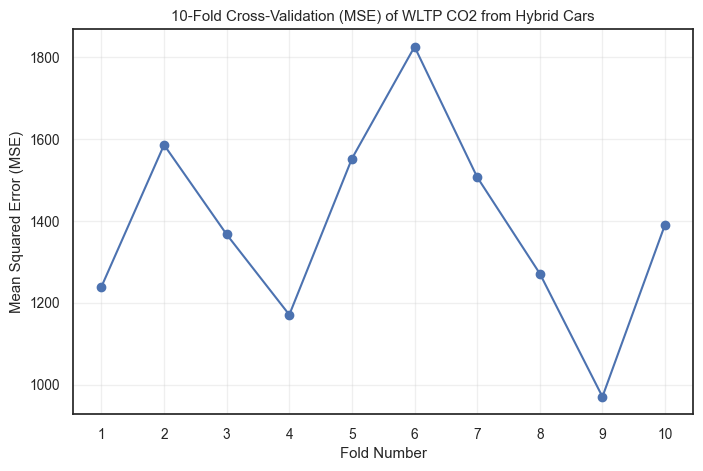

In [1286]:
# data validation for hybrid cars, target variable: WLTP CO2
tenfold_dataValidation("WLTP CO2", data_hybrid)

10-fold CV MSE scores: [42.27947119632712, 47.956806391015, 66.14828240354515, 57.94611387863636, 33.30093578990461, 42.873359949927355, 42.90273724034652, 36.751902710119815, 56.835284641779026, 39.163033607400436]
Mean MSE: 46.615792780900144
Validation MSE: 71.62983677331997
Test MSE: 24.3941498342779


Validation RMSE: 8.463441189806895
Test RMSE: 4.939043412876415


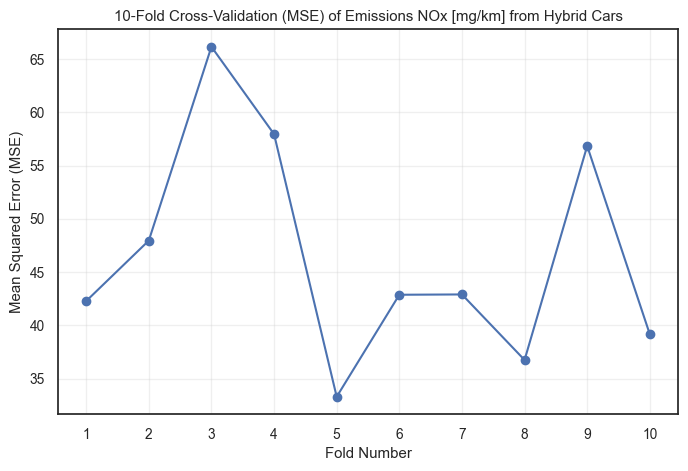

In [1287]:
# data validation for hybrid cars, target variable: Emissions NOx [mg/km]
tenfold_dataValidation("Emissions NOx [mg/km]", data_hybrid)

In [1288]:
def feature_select_lasso(
    X_train, X_test, y_train, y_test, *,
    X_val=None, y_val=None,                    # <-- NEW (optional)
    validation_mode="merge",                   # "merge" or "separate"
    refit_after_cv=True,                       # only used when validation_mode="separate"
    features=None,
    dataset_name="Dataset",
    cv=10,
    random_state=42,
    max_iter=5000,
    show_plots=True
):
    """
    Lasso feature selection with 10-fold CV + learning curve.
    Supports 3-way split via `validation_mode`:
      - "merge":   CV+fit on train+val, test on test (recommended)
      - "separate":CV on train only; report val metrics; optionally refit on train+val
    """

    # --------- choose columns ---------
    use_cols = X_train.columns.tolist() if features is None else list(dict.fromkeys(features))
    for c in use_cols:
        if c not in X_train.columns: raise ValueError(f"Missing column in X_train: {c}")
    Xtr, Xte = X_train[use_cols].copy(), X_test[use_cols].copy()
    Xva = None if X_val is None else X_val[use_cols].copy()

    # --------- preprocessing ---------
    num_cols = Xtr.select_dtypes(include=["float64","int64"]).columns.tolist()
    cat_cols = [c for c in use_cols if c not in num_cols]
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="mean")),
                          ("sc",  StandardScaler())]), num_cols),
        ("cat", "drop", cat_cols)
    ])

    # --------- choose fitting data ---------
    if validation_mode == "merge" and X_val is not None and y_val is not None:
        Xfit = pd.concat([Xtr, Xva], axis=0)
        yfit = pd.concat([y_train, y_val], axis=0)
        fit_label = "train+val"
    else:
        Xfit, yfit = Xtr, y_train
        fit_label = "train"

    # --------- CV model on fitting data ---------
    cv_model = LassoCV(cv=cv, random_state=random_state, max_iter=max_iter)
    pipe_cv = Pipeline([("pre", pre), ("model", cv_model)])
    pipe_cv.fit(Xfit, yfit)
    alpha_star = pipe_cv.named_steps["model"].alpha_

    # --------- optional refit (separate mode) ---------
    final_pipe = pipe_cv
    if validation_mode == "separate" and refit_after_cv and X_val is not None and y_val is not None:
        # lock alpha and refit on train+val for the fairest test estimate
        final_model = Lasso(alpha=alpha_star, random_state=random_state, max_iter=max_iter)
        final_pipe = Pipeline([("pre", pre), ("model", final_model)])
        final_pipe.fit(pd.concat([Xtr, Xva]), pd.concat([y_train, y_val]))
        fit_label = "train+val (refit with fixed α)"

    # --------- predictions ---------
    yhat_tr = final_pipe.predict(Xtr)
    yhat_te = final_pipe.predict(Xte)
    yhat_va = None if Xva is None else final_pipe.predict(Xva)

    # --------- metrics (RSS + MSE) ---------
    rss_train = float(np.sum((y_train - yhat_tr)**2))
    mse_train = float(mean_squared_error(y_train, yhat_tr))
    rss_test  = float(np.sum((y_test  - yhat_te)**2))
    mse_test  = float(mean_squared_error(y_test,  yhat_te))

    rss_val = mse_val = None
    if Xva is not None and y_val is not None:
        rss_val = float(np.sum((y_val - yhat_va)**2))
        mse_val = float(mean_squared_error(y_val, yhat_va))

    print(f"\n==================== {dataset_name.upper()} ====================")
    print(f"Features ({len(use_cols)}): {use_cols}")
    print(f"Validation mode: {validation_mode} | Fitted on: {fit_label}")
    print(f"Chosen alpha (λ) from CV: {alpha_star:.6f}")
    if mse_val is not None:
        print(f"VAL  RSS: {rss_val:.2f} | VAL  MSE: {mse_val:.2f}")
    print(f"TRAIN RSS: {rss_train:.2f} | TRAIN MSE: {mse_train:.2f}")
    print(f"TEST  RSS: {rss_test:.2f} | TEST  MSE: {mse_test:.2f}")

    # --------- overfit check ---------
    ratio = rss_test / rss_train if rss_train>0 else np.inf
    gap   = (mse_test - mse_train)/mse_train*100 if mse_train>0 else np.inf
    status = "OK"
    if ratio>2 or gap>50: status="Possible overfit"
    elif ratio<0.6 and gap<-30: status="Well-regularised / easy test split"
    print(f"Overfit check → RSS ratio {ratio:.2f}, MSE gap {gap:.1f}% → {status}")

    # --------- learning curve (on the data used for CV) ---------
    train_sizes, tr_scores, va_scores = learning_curve(
        pipe_cv, Xfit, yfit, cv=cv, scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=random_state
    )
    lc_train = -tr_scores.mean(axis=1)
    lc_val   = -va_scores.mean(axis=1)

    # --------- plots ---------
    if show_plots:
        fig, axs = plt.subplots(2, 2, figsize=(12,8))
        fig.suptitle(f"{dataset_name} – LassoCV Diagnostics", fontsize=14, fontweight="bold")

        # CV curve from the CV model
        axs[0,0].semilogx(pipe_cv.named_steps["model"].alphas_,
                          pipe_cv.named_steps["model"].mse_path_.mean(axis=1), marker='.')
        axs[0,0].axvline(alpha_star, ls='--', color='r')
        axs[0,0].set_title(f"CV MSE vs Alpha ({cv}-fold)")
        axs[0,0].set_xlabel("Alpha (λ)"); axs[0,0].set_ylabel("Mean CV MSE")

        # Predicted vs Actual (test)
        axs[0,1].scatter(y_test, yhat_te)
        lo, hi = float(np.min(y_test)), float(np.max(y_test))
        axs[0,1].plot([lo, hi], [lo, hi], 'r--')
        axs[0,1].set_title("Predicted vs Actual (Test)")
        axs[0,1].set_xlabel("Actual WLTP CO2"); axs[0,1].set_ylabel("Predicted WLTP CO2")

        # Learning curve (on Xfit/yfit)
        axs[1,0].plot(train_sizes, lc_train, 'o-', label="Train MSE")
        axs[1,0].plot(train_sizes, lc_val,   's-', label="Validation MSE")
        axs[1,0].set_title(f"Learning Curve on {fit_label}")
        axs[1,0].set_xlabel("Training set size"); axs[1,0].set_ylabel("MSE"); axs[1,0].legend()

        # Coefficients
        coef = final_pipe.named_steps["model"].coef_
        names = final_pipe.named_steps["pre"].get_feature_names_out()
        axs[1,1].barh(names, coef); axs[1,1].set_title("Lasso Coefficients")
        axs[1,1].set_xlabel("Coefficient")
        plt.tight_layout(); plt.show()

    # --------- return ---------
    return {
        "dataset": dataset_name,
        "features": use_cols,
        "alpha": float(alpha_star),
        "mode": validation_mode,
        "fitted_on": fit_label,
        "rss_train": rss_train, "mse_train": mse_train,
        "rss_val": rss_val,     "mse_val": mse_val,
        "rss_test": rss_test,   "mse_test": mse_test,
        "overfit_flag": status,
        "learning_curve": {"train_sizes": train_sizes, "train_mse": lc_train, "val_mse": lc_val}
    }, final_pipe

In [1289]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]
fuel_feats = ['Manual or Automatic', 'Engine Capacity', 'Engine Power (PS)', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'Emissions NOx [mg/km]']
res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    X_val=X_val, y_val=y_val,
    validation_mode="separate",
    features=fuel_feats, cv=10, show_plots=True
)


==================== FUEL (ALL) ====================


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
# Example 1 — Fuel: manually pick columns
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_fuel)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]
fuel_feats = ['Engine Capacity', 'Engine Power (PS)','WLTP Imperial Combined']
res_fuel_manual, pipe_fuel_manual = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    X_val=X_val, y_val=y_val,
    validation_mode="separate",
    features=fuel_feats, cv=10, show_plots=True
)


==================== FUEL (LESS) ====================


AttributeError: 'numpy.ndarray' object has no attribute 'columns'


==================== DATASET ====================
Features (22): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium', 'WLTP Imperial High', 'WLTP Imperial Extra High', 'WLTP Imperial Combined', 'WLTP Imperial Combined (Weighted)', 'WLTP Metric Low', 'WLTP Metric Medium', 'WLTP Metric High', 'WLTP Metric Extra High', 'WLTP Metric Combined', 'WLTP Metric Combined (Weighted)', 'Emissions NOx [mg/km]', 'Manual or Automatic_Electric - Not Applicable', 'Manual or Automatic_Manual', 'Fuel Type_Electricity / Petrol', 'Fuel Type_Petrol Electric', 'Powertrain_Mild Hybrid Electric Vehicle (MHEV)', 'Powertrain_Plug-in Hybrid Electric Vehicle (PHEV)', 'Powertrain_Range Extended Electric Vehicle (REEV)']
Validation mode: merge | Fitted on: train+val
Chosen alpha (λ) from CV: 0.076046
VAL  RSS: 28158.79 | VAL  MSE: 166.62
TRAIN RSS: 389455.68 | TRAIN MSE: 289.34
TEST  RSS: 38995.67 | TEST  MSE: 232.12
Overfit check → RSS ratio 0.10, MSE gap -19.8% → OK


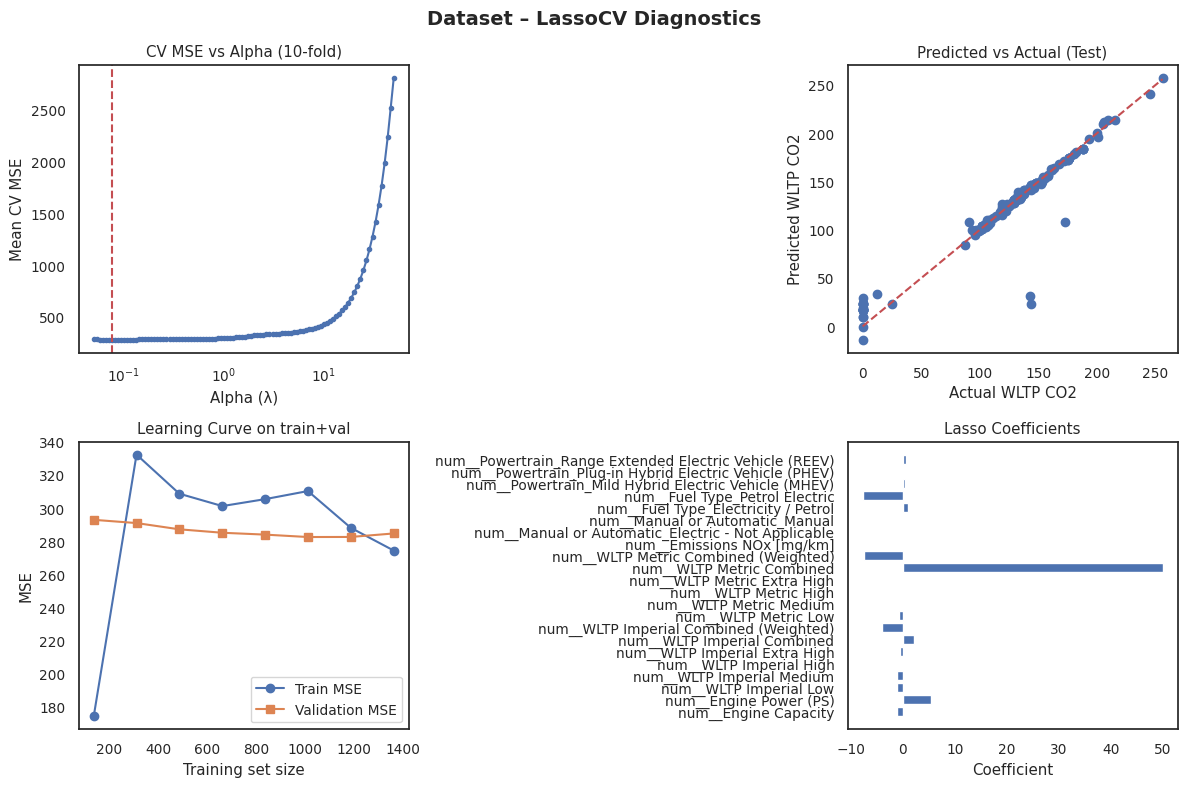

In [ ]:
# Example 2 — Hybrid: use all columns (features=None)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_hybrid_all, pipe_hybrid_all = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    X_val=X_val, y_val=y_val,
    validation_mode="merge",
    features=None, cv=10, show_plots=True
)


==================== DATASET ====================
Features (3): ['Engine Capacity', 'Engine Power (PS)', 'WLTP Imperial Combined']
Validation mode: merge | Fitted on: train+val
Chosen alpha (λ) from CV: 0.028776
VAL  RSS: 317834.01 | VAL  MSE: 1880.67
TRAIN RSS: 2791518.04 | TRAIN MSE: 2073.94
TEST  RSS: 349695.94 | TEST  MSE: 2081.52
Overfit check → RSS ratio 0.13, MSE gap 0.4% → OK


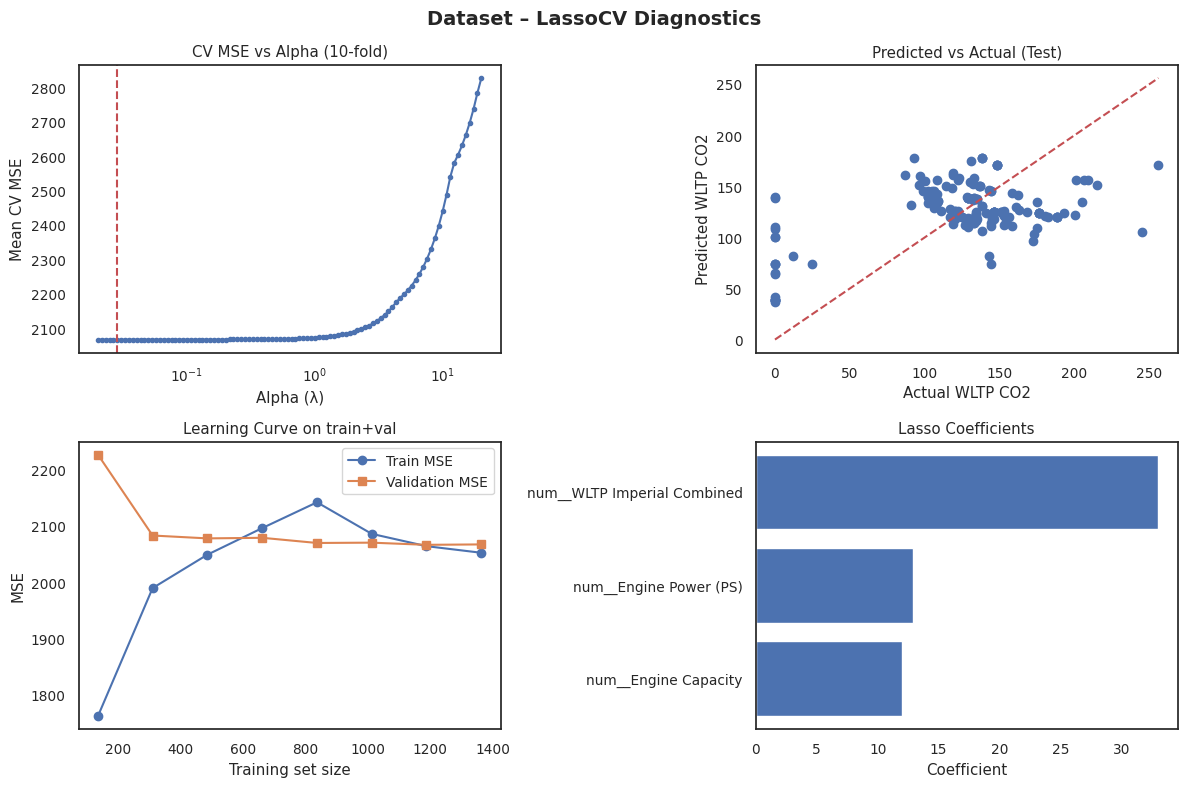

In [ ]:
# Example 3 — Lock alpha to a known value (e.g., from a previous CV run)
(X_train, X_val, X_test, y_train, y_val, y_test) = [
    data_split("WLTP CO2", data_hybrid)[k] for k in
    ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]
]

res_fuel_locked, pipe_fuel_locked = feature_select_lasso(
    X_train, X_test, y_train, y_test,
    X_val=X_val, y_val=y_val,
    validation_mode="merge",
    features=fuel_feats, cv=10, show_plots=True
)

## Neural Network - Regression Tasks

**Variables Selection**
The following variables should be used to develop neural networks model.


In [ ]:
#print current variables from the fuel cars dataset
print(data_fuel.columns)
print(data_fuel.shape)

Index(['Manual or Automatic', 'Engine Capacity', 'Fuel Type', 'Powertrain',
       'Engine Power (PS)', 'WLTP Imperial Low', 'WLTP Imperial Medium',
       'WLTP Imperial High', 'WLTP Imperial Extra High',
       'WLTP Imperial Combined', 'WLTP CO2', 'Emissions NOx [mg/km]'],
      dtype='object')
(1233, 12)


### Neural Network Regression (2 Layers)

Training RMSE: 12.436522270425003
Coefficient of determination (R²) on training data: 0.9493
Test RMSE: 44.10646512417278
Coefficient of determination (R²) on test data: 0.1327
Validation RMSE: 56.4464054374124
Coefficient of determination (R²) on  validation data: 0.1247


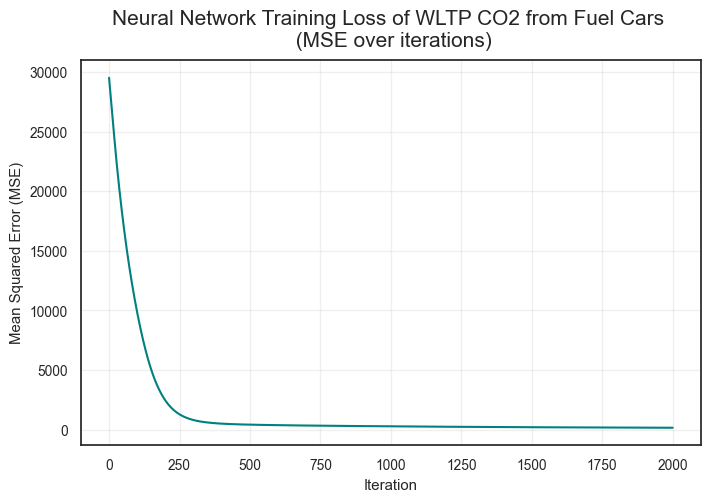

In [1292]:
# Reusable function for Neural Network regression task - simple 1 hidden layer NN
def neural_network_regression(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    #reuse this part to access the splitted data.
    splits = data_split(target, data)

    # Access the data 
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)
    
    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features - 12
    D_out = 1 # number of outputs
    H = 20 # number of hidden neurons, based on number of features

    # Initialize weights
    W0 = normal(0, 0.1, size=(D_in, H))
    W1 = normal(0, 0.1, size=(H, D_out))

    # Training loop
    eta = 0.0005

    loss_history = []
    for i in range(2001):
        # forward pass
        
        ## Bias Terms
        b0 = np.zeros((1, H))
        b1 = np.zeros((1, 1))
        # z1 = X.dot(W0) + b0
        # a2 = a1.dot(W1) + b1

        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500)
        a1 = 1 / (1 + np.exp(-z1))
        a2 = a1.dot(W1) + b1
        Loss = np.mean((a2 - y_train) ** 2)
        loss_history.append(Loss)

        # # print loss every 100 iterations
        # if i % 100 == 0:
        #     print(f"Iteration {i}: Loss {Loss:.4f}")
    
        # backward pass
        da2 = 2.0 * (a2 - y_train)
        dW1 = a1.T.dot(da2) / N
        da1 = da2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train.T.dot(dz1) / N
        
        # update
        W0 -= eta * dW0 # weights update for features
        W1 -= eta * dW1

    # Evaluate
    z1 = X_train.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_pred = a1.dot(W1)

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1 = X_test.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_test_pred = a1.dot(W1)

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1 = X_val.dot(W0)
    z1 = np.clip(z1, -500, 500)
    a1 = 1 / (1 + np.exp(-z1))
    y_val_pred = a1.dot(W1)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_fuel)

Training RMSE: 14.815981434851306
Coefficient of determination (R²) on training data: 0.105
Test RMSE: 11.829904730746025
Coefficient of determination (R²) on test data: 0.065
Validation RMSE: 12.647408652911807
Coefficient of determination (R²) on  validation data: 0.0625


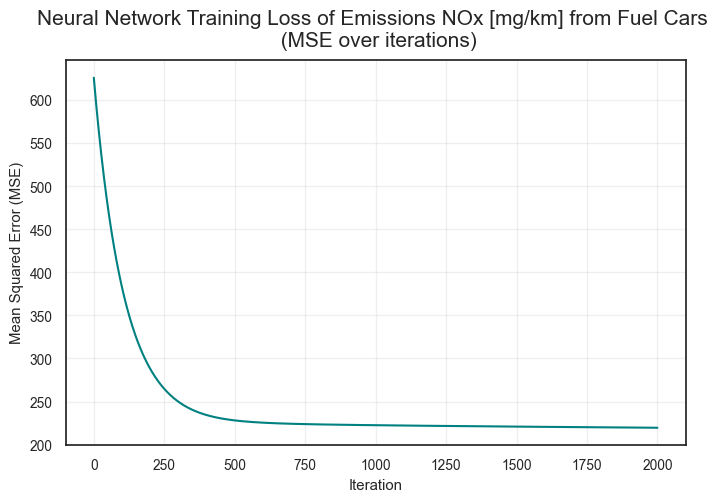

In [1293]:
# Neural Network regression for fuel cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 38.19239826571817
Coefficient of determination (R²) on training data: 0.5026
Test RMSE: 38.44982940941212
Coefficient of determination (R²) on test data: 0.4678
Validation RMSE: 30.23993133499338
Coefficient of determination (R²) on  validation data: 0.5482


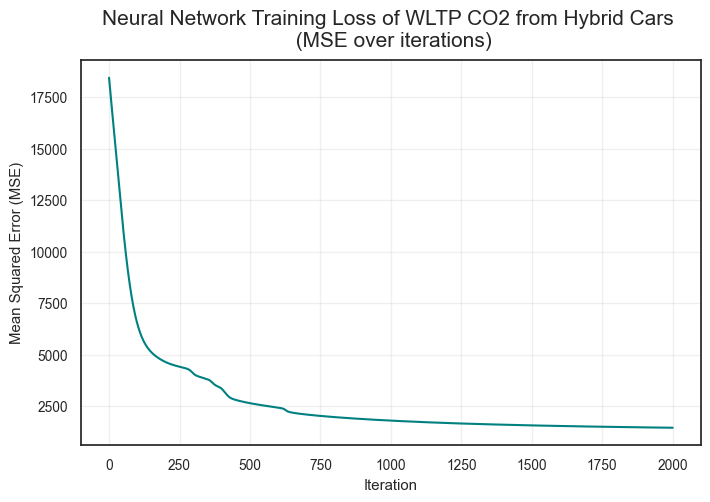

In [1294]:
# Neural Network regression for hybrid cars, target variable: WLTP CO2
neural_network_regression("WLTP CO2", data_hybrid)

Training RMSE: 6.948331299393142
Coefficient of determination (R²) on training data: 0.3586
Test RMSE: 4.5569826960276325
Coefficient of determination (R²) on test data: 0.5395
Validation RMSE: 8.553670908226573
Coefficient of determination (R²) on  validation data: 0.2648


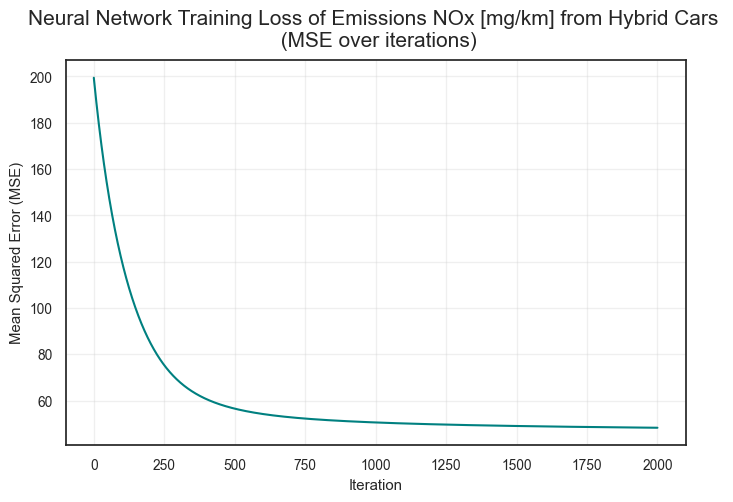

In [1295]:
# Neural Network regression for hybrid cars, target variable: Emissions NOx [mg/km]
neural_network_regression("Emissions NOx [mg/km]", data_hybrid)

In [ ]:
# #Examine weights from the NNR
# import io, contextlib

# buf = io.StringIO()
# with contextlib.redirect_stdout(buf):  # hide print outputs
#     res = neural_network_regression("WLTP CO2", data_fuel);

# # from your Regressor() output
# W0 = res["W0"]                    # shape: [n_features, H]
# features = res["features"]
# imp = np.mean(np.abs(W0), axis=1)

# print("W0 shape:", W0.shape)
# print("Number of features:", len(features))

# # Ensure they match in length
# min_len = min(len(features), len(imp))
# features = features[:min_len]
# imp = imp[:min_len]

# imp_df = pd.DataFrame({"Feature": features, "Importance": imp})
# imp_df = imp_df.sort_values(by="Importance", ascending=True)



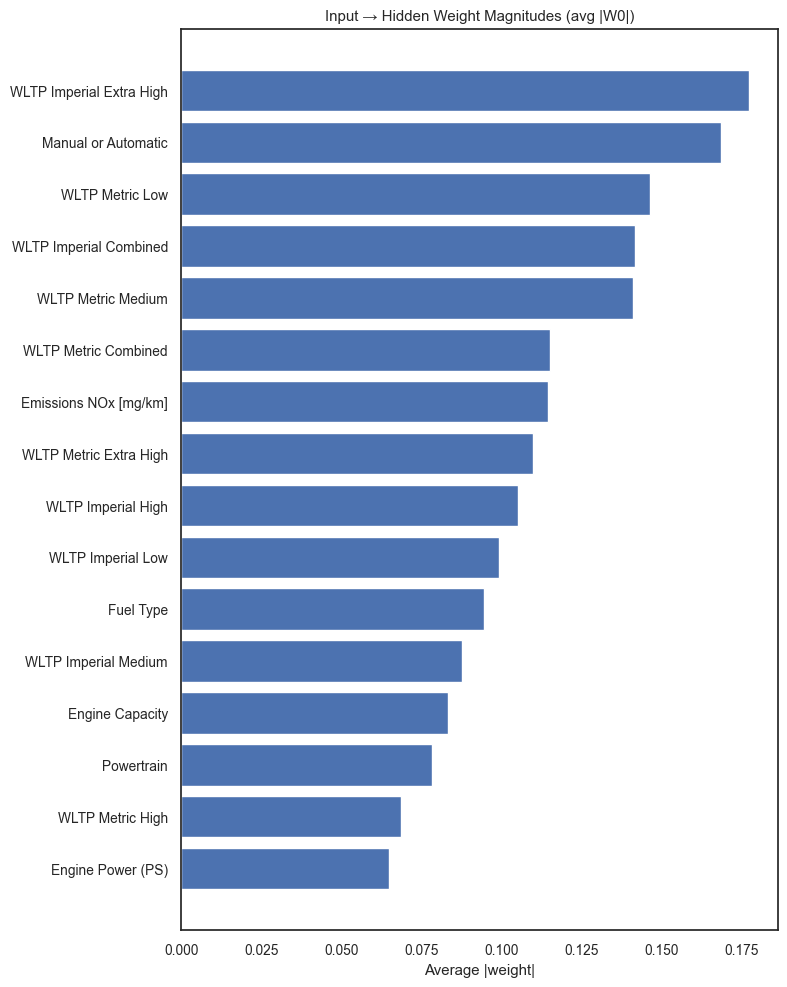

In [ ]:
# importance = average absolute incoming weight to hidden layer
plt.figure(figsize=(8, 10))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.title("Input → Hidden Weight Magnitudes (avg |W0|)")
plt.xlabel("Average |weight|")
plt.tight_layout()
plt.show()

### Neural Network Regression - 3 Layers

Training RMSE: 15.510782518010755
Coefficient of determination (R²) on training data: 0.9211
Test RMSE: 17.944489791782775
Coefficient of determination (R²) on test data: 0.8564
Validation RMSE: 20.247365442063554
Coefficient of determination (R²) on  validation data: 0.8874


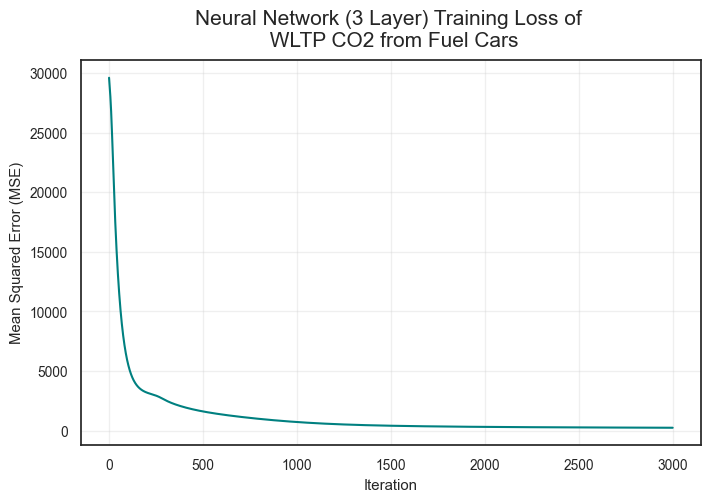

In [1319]:
# Reusable function for Neural Network regression task - 2 hidden layer NN
def neural_network_regression_2hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    splits = data_split(target, data)

    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]      

    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)

    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train)
    # X_test_scaled = scaler.transform(X_test)
    # X_val_scaled = scaler.transform(X_val)

    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    H1 = 30 # number of hidden neurons in hidden layer 1
    H2 = 20 # number of hidden neurons in hidden layer 2

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Output: hidden2 -> output
    W2 = normal(0, 0.1, size=(H2, D_out))
    b2 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0003

    loss_history = []
    for i in range(3001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1.0 / (1.0 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1.0 / (1.0 + np.exp(-z2)) # sigmoid

        # Output (linear)
        y_hat = a2.dot(W2) + b2

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))

        # ---- backward pass ----
        # dLoss/dy_hat = 2*(y_hat - y) / N
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a2 -> y_hat)
        dW2 = a2.T.dot(dy)     
        db2 = np.sum(dy, axis=0, keepdims=True) 

        # Backprop into hidden2
        da2 = dy.dot(W2.T)                        
        dz2 = da2 * a2 * (1.0 - a2)               
        dW1 = a1.T.dot(dz2)                       
        db1 = np.sum(dz2, axis=0, keepdims=True)  

        # Backprop into hidden1
        da1 = dz2.dot(W1.T)                       
        dz1 = da1 * a1 * (1.0 - a1)               
        dW0 = X_train.T.dot(dz1)           
        db0 = np.sum(dz1, axis=0, keepdims=True) 

        # ---- update parameters ----
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1
        W0 -= eta * dW0
        b0 -= eta * db0

    # # Evaluate
    # z1 = X_train_scaled.dot(W0)
    # z1 = np.clip(z1, -500, 500)
    # a1 = 1 / (1 + np.exp(-z1))
    # y_pred = a1.dot(W2)

    # Evaluate on training set
    z1_ = X_train.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    
    y_pred = a2_.dot(W2) + b2

    # MSE and RMSE on training data
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_pred),4))

    # Evaluate on test set
    z1_ = X_test.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_test_pred = a2_.dot(W2) + b2

    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    z1_ = X_val.dot(W0) + b0
    z1_ = np.clip(z1_, -500, 500)
    a1_ = 1.0 / (1.0 + np.exp(-z1_))
    z2_ = a1_.dot(W1) + b1
    z2_ = np.clip(z2_, -500, 500)
    a2_ = 1.0 / (1.0 + np.exp(-z2_))
    y_val_pred = a2_.dot(W2) + b2
    
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"

    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (3 Layer) Training Loss of \n {target} from {data_label}",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_2hidden("WLTP CO2", data_fuel)

Training RMSE: 15.372476703003027
Coefficient of determination (R²) on training data: 0.0365
Test RMSE: 12.235665239745233
Coefficient of determination (R²) on test data: -0.0003
Validation RMSE: 12.781698121693413
Coefficient of determination (R²) on  validation data: 0.0425


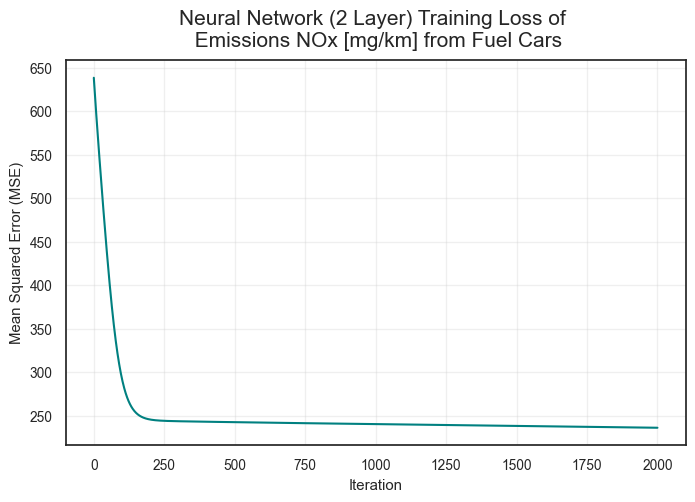

In [1317]:
# NN Regression (2 hidden layers), Emissions NOx from Fuel cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 35.400911431061
Coefficient of determination (R²) on training data: 0.5726
Test RMSE: 32.567133757625534
Coefficient of determination (R²) on test data: 0.6182
Validation RMSE: 32.620108791396056
Coefficient of determination (R²) on  validation data: 0.4743


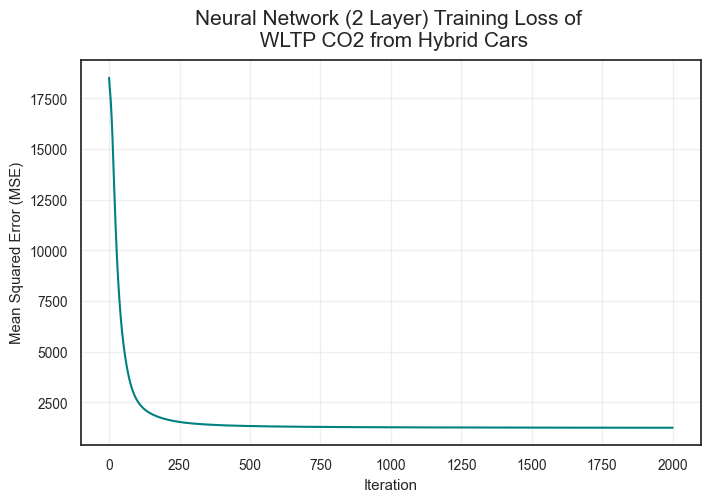

In [1300]:
# NN Regression (2 hidden layers), CO2 emissions from Hybrid cars
neural_network_regression_2hidden("WLTP CO2", data_hybrid)

Training RMSE: 7.82845367219949
Coefficient of determination (R²) on training data: 0.1858
Test RMSE: 5.67582316299329
Coefficient of determination (R²) on test data: 0.2856
Validation RMSE: 9.273860012605462
Coefficient of determination (R²) on  validation data: 0.1357


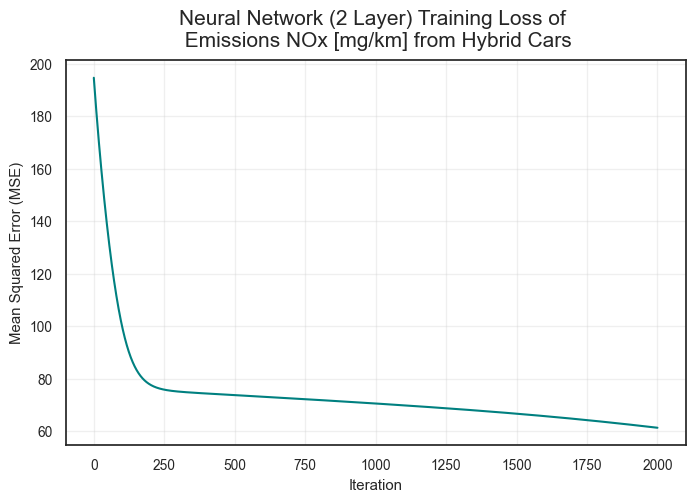

In [1301]:
# NN Regression (2 hidden layers), Emissions NOx from Hybrid cars
neural_network_regression_2hidden("Emissions NOx [mg/km]", data_hybrid)

### Neural Network Regression - 4 Layers

Training RMSE: 138.34888663549498
Coefficient of determination (R²) on training data: -5.2739
Test RMSE: 141.7315282999684
Coefficient of determination (R²) on test data: -7.9554
Validation RMSE: 151.59561325673613
Coefficient of determination (R²) on  validation data: -5.3135


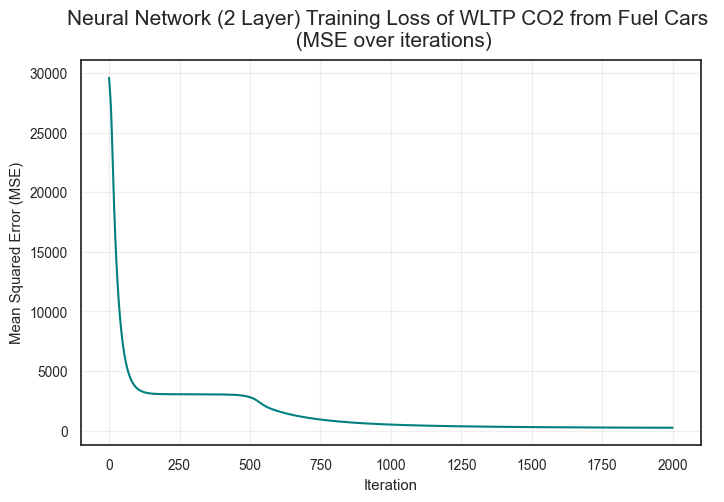

In [1308]:
# Reusable function for Neural Network regression task - 3 hidden layer NN

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def neural_network_regression_3hidden(target: str, data: pd.DataFrame, random_state: int = 42):
    assert target in data.columns, f"Target '{target}' not in dataframe."

    # Perform data splitting
    splits = data_split(target, data)   
    
    X_train = splits["X_train"]
    X_val   = splits["X_val"]
    X_test  = splits["X_test"]
    y_train = splits["y_train"]   
    y_val   = splits["y_val"]
    y_test  = splits["y_test"]
    
    # Flatten target arrays
    y_train = y_train.values.reshape(-1, 1)
    y_val   = y_val.values.reshape(-1, 1)
    y_test  = y_test.values.reshape(-1, 1)


    # Define NN dimensions
    N = len(y_train) # number of samples
    D_in = X_train.shape[1] # number of features
    D_out = 1 # number of outputs
    
    H1 = 40 # number of hidden neurons in hidden layer 1
    H2 = 30 # number of hidden neurons in hidden layer 2
    H3 = 20 # number of hidden neurons in hidden layer 3

    # -- Initialize weights
    # Layer 1: input -> hidden1
    W0 = normal(0, 0.1, size=(D_in, H1))
    b0 = np.zeros((1, H1))

    # Layer 2: hidden1 -> hidden2
    W1 = normal(0, 0.1, size=(H1, H2))
    b1 = np.zeros((1, H2))

    # Layer 3: hidden2 -> hidden3
    W2 = normal(0, 0.1, size=(H2, H3))
    b2 = np.zeros((1, H3))

    # Output: hidden3 -> output
    W3 = normal(0, 0.1, size=(H3, D_out))
    b3 = np.zeros((1, D_out))
    
    # Training loop
    eta = 0.0005

    loss_history = []
    for i in range(2001):
        # ---- forward pass ----
        ## Layer 1
        z1 = X_train.dot(W0) + b0
        z1 = np.clip(z1, -500, 500) 
        a1 = 1 / (1 + np.exp(-z1)) # sigmoid

        # Layer 2
        z2 = a1.dot(W1) + b1
        z2 = np.clip(z2, -500, 500)
        a2 = 1 / (1 + np.exp(-z2)) # sigmoid

        # Layer 3
        z3 = a2.dot(W2) + b2
        z3 = np.clip(z3, -500, 500)
        a3 = 1 / (1 + np.exp(-z3)) # sigmoid

        # Output (linear)
        y_hat = a3.dot(W3) + b3

        # Loss (MSE)
        Loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(float(Loss))


        # ---- backward pass ----
        dy = (2.0 / N) * (y_hat - y_train)

        # Gradients for output layer (a3 -> y_hat)
        dW3 = a3.T.dot(dy)       
        db3 = np.sum(dy, axis=0, keepdims=True)

        # Backprop into hidden3
        da3 = dy.dot(W3.T)
        dz3 = da3 * a3 * (1 - a3)
        dW2 = a2.T.dot(dz3)
        db2 = np.sum(dz3, axis=0, keepdims=True)
        
        # Backprop into hidden2
        da2 = dz3.dot(W2.T)
        dz2 = da2 * a2 * (1 - a2)
        dW1 = a1.T.dot(dz2)
        db1 = np.sum(dz2, axis=0, keepdims=True)
        
        # Backprop into hidden1
        da1 = dz2.dot(W1.T)
        dz1 = da1 * a1 * (1 - a1)
        dW0 = X_train.T.dot(dz1)
        db0 = np.sum(dz1, axis=0, keepdims=True)
 
        # ---- update parameters ----
        W3 -= eta * dW3
        b3 -= eta * db3
        
        W2 -= eta * dW2
        b2 -= eta * db2
        
        W1 -= eta * dW1
        b1 -= eta * db1
        
        W0 -= eta * dW0
        b0 -= eta * db0

    # Evaluate on training set
    def predict(X):
        z1 = X.dot(W0) + b0
        z1_ = np.clip(z1, -500, 500)
        a1 = 1.0 / (1.0 + np.exp(-z1_))
        
        z2 = a1.dot(W1) + b1
        z2_ = np.clip(z2, -500, 500)
        a2 = np.clip(z2_, -500, 500)
        
        z3 = a2.dot(W2) + b2
        z3_ = np.clip(z3, -500, 500)
        a3 = 1.0 / (1.0 + np.exp(-z3_))

        return a3.dot(W3) + b3

    
    # z1 = X_train_scaled.dot(W0) + b0
    # z1_ = np.clip(z1, -500, 500)
    # a1 = 1.0 / (1.0 + np.exp(-z1_))
        
    # z2 = a1.dot(W1) + b1
    # z2_ = np.clip(z2, -500, 500)
    # a2 = np.clip(z2_, -500, 500)
    
    # z3 = a2.dot(W2) + b2
    # z3_ = np.clip(z3, -500, 500)
    # a3 = 1.0 / (1.0 + np.exp(-z3_))
    # y_train_pred = a3.dot(W3) + b3

    # MSE and RMSE on training data
    y_train_pred = predict(X_train)
    print('Training RMSE:', np.sqrt(mean_squared_error(y_train, y_train_pred)))
    print('Coefficient of determination (R²) on training data:', round(r2_score(y_train, y_train_pred),4))

    # Evaluate on test set
    y_test_pred = predict(X_test)
    print('Test RMSE:', np.sqrt(mean_squared_error(y_test, y_test_pred)))
    print('Coefficient of determination (R²) on test data:', round(r2_score(y_test, y_test_pred),4))

    # Evaluate on validation set
    y_val_pred = predict(X_val)
    print('Validation RMSE:', np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print('Coefficient of determination (R²) on  validation data:', round(r2_score(y_val, y_val_pred),4))


    # Auto labeling based on Fuel Type column
    if data["Fuel Type"].isin(fuel_types).any():
        data_label = "Fuel Cars"
    elif data["Fuel Type"].isin(hybrid_types).any():
        data_label = "Hybrid Cars"
    else:
        data_label = "Dataset"


    #Visualise the MSE
    plt.figure(figsize=(8,5))
    plt.plot(loss_history, color='teal')
    plt.title(f"Neural Network (2 Layer) Training Loss of {target} from {data_label} \n (MSE over iterations)",
              fontsize = 15, pad = 10)
    plt.xlabel("Iteration")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.grid(alpha=0.3)
    plt.show()

    # # Return the weights and features of the model
    # return{
    #     "features": features,
    #     "W0": W0
    #     }

# Neural Network regression for fuel cars, target variable: WLTP CO2
neural_network_regression_3hidden("WLTP CO2", data_fuel)

Training RMSE: 15.59856461401389
Coefficient of determination (R²) on training data: 0.0079
Test RMSE: 12.147272538994773
Coefficient of determination (R²) on test data: 0.0141
Validation RMSE: 12.921413851143056
Coefficient of determination (R²) on  validation data: 0.0215


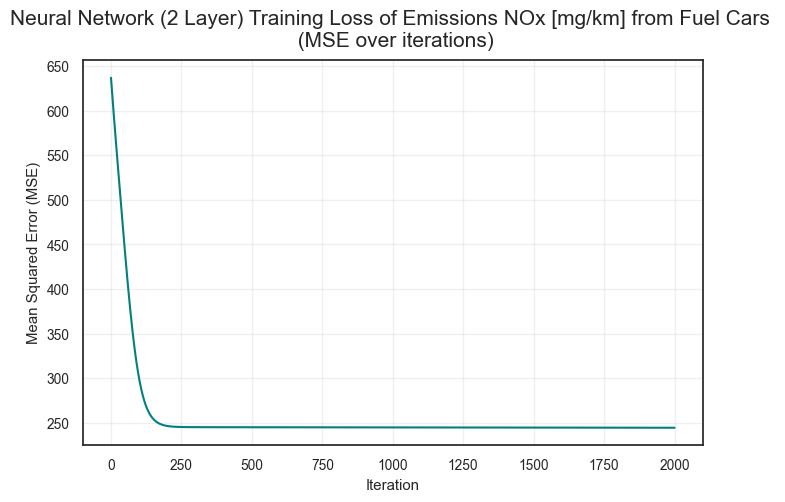

In [1311]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_fuel)

Training RMSE: 68.1218548774973
Coefficient of determination (R²) on training data: -0.5826
Test RMSE: 68.01839705992786
Coefficient of determination (R²) on test data: -0.6655
Validation RMSE: 72.09753442118979
Coefficient of determination (R²) on  validation data: -1.5681


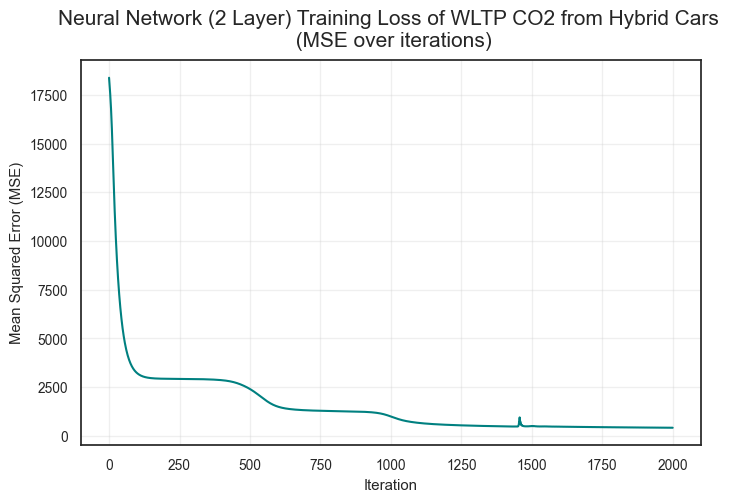

In [1312]:
neural_network_regression_3hidden("WLTP CO2", data_hybrid)

Training RMSE: 8.584087230370482
Coefficient of determination (R²) on training data: 0.0211
Test RMSE: 6.449273594905352
Coefficient of determination (R²) on test data: 0.0777
Validation RMSE: 10.029009351193174
Coefficient of determination (R²) on  validation data: -0.0107


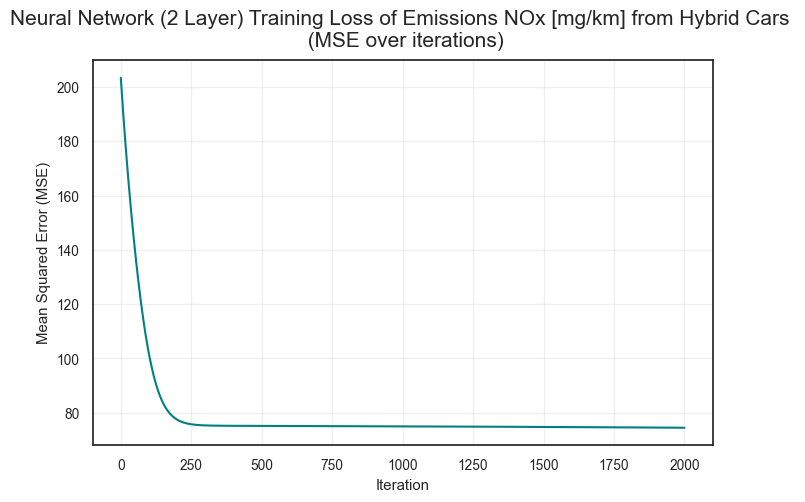

In [1313]:
neural_network_regression_3hidden("Emissions NOx [mg/km]", data_hybrid)